# Introduction to Logistic Regression



In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.offline as py
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

from scipy.optimize import minimize

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV


In [3]:
# formatting options

# big font helper
def adjust_fontsize(size=None):
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12
    if size != None:
        SMALL_SIZE = MEDIUM_SIZE = BIGGER_SIZE = size
    plt.rcParams['font.size'] = SMALL_SIZE
    plt.rcParams['axes.titlesize'] = SMALL_SIZE
    plt.rcParams['axes.labelsize'] = MEDIUM_SIZE
    plt.rcParams['xtick.labelsize'] = SMALL_SIZE
    plt.rcParams['ytick.labelsize'] = SMALL_SIZE
    plt.rcParams['legend.fontsize'] = SMALL_SIZE
    plt.rcParams['figure.titlesize'] = BIGGER_SIZE
    # plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
    # plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
    # plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
    # plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    # plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    # plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
    # plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
    
def savefig(fname):
    if not os.path.exists("images"):
        os.mkdir("images")
    fig = plt.gcf()
    fig.patch.set_alpha(0.0)
    plt.savefig(f"images/{fname}.png", bbox_inches = 'tight');
    
    
# plt.rcParams['figure.figsize'] = (4, 4)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['lines.linewidth'] = 3

plt.style.use('fivethirtyeight')
sns.set_context("talk")
sns.set_theme()
#sns.set()
adjust_fontsize(20)


---

## Obtaining the Data

For this lecture, we will use the Wisconsin Breast Cancer Dataset which we can obtain from scikit learn: 

- [breast cancer dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset)

- [documentation about this dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset)

This dataset consists of measurements from tumor biopsies for 569 patients as well as whether the tumor was malignant or benign.

In [6]:
import sklearn.datasets
data_dict = sklearn.datasets.load_breast_cancer()
data = pd.DataFrame(data_dict['data'], columns=data_dict['feature_names'])
data

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### The Prediction Task

The prediction task for this data is to predict whether a tumor is benign or malignant (a binary decision) given characteristics of that tumor. As a classic machine learning dataset, the prediction task is captured by the column named `"target"`.  
The documentation about this dataset indicates that the target variable is storing "1" as benign and "0" as malignant.  

To put the data back in it's original context we will create a new column called `"malignant"` which will be 1 if the tumor is malignant and 0 if it is benign (reversing the definition of target).  

In [8]:
# Target data_dict['target'] = 0 is malignant 1 is benign
# For our purposes, a 1 will mean malignant:
data['malignant'] = (data_dict['target'] == 0).astype(int)

### Selecting Features

What features might be a good indication of whether a tumor is benign or malignant? 

In [10]:
data.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'malignant'],
      dtype='object')

In [11]:
data[['mean radius', 'malignant']]

,mean radius,malignant
0,17.99,1
1,20.57,1
2,19.69,1
3,11.42,1
4,20.29,1
...,...,...
564,21.56,1
565,20.13,1
566,16.60,1
567,20.60,1


Perhaps a good starting point is the size of the tumor.  Larger tumors are probably more likely to be malignant.  In the following, we plot whether the tumor was malignant (1 or 0) against the `"mean radius"`.

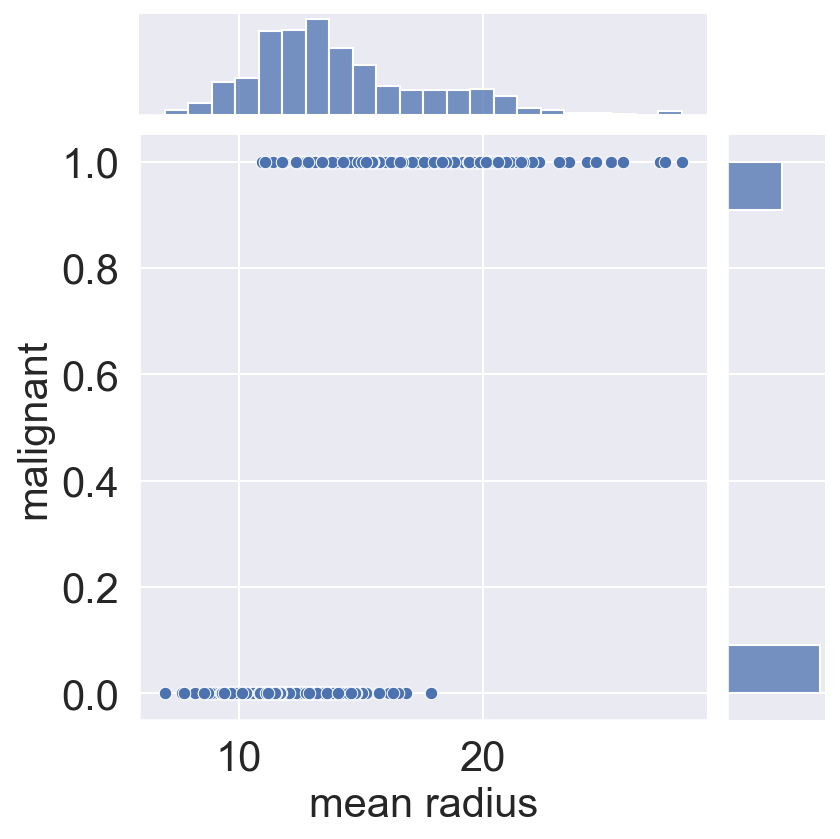

In [13]:
sns.jointplot(data = data, x = "mean radius", y = "malignant");
#savefig("overplot")

This is a clear example of over-plotting.  We can improve the above plot by jittering the data:

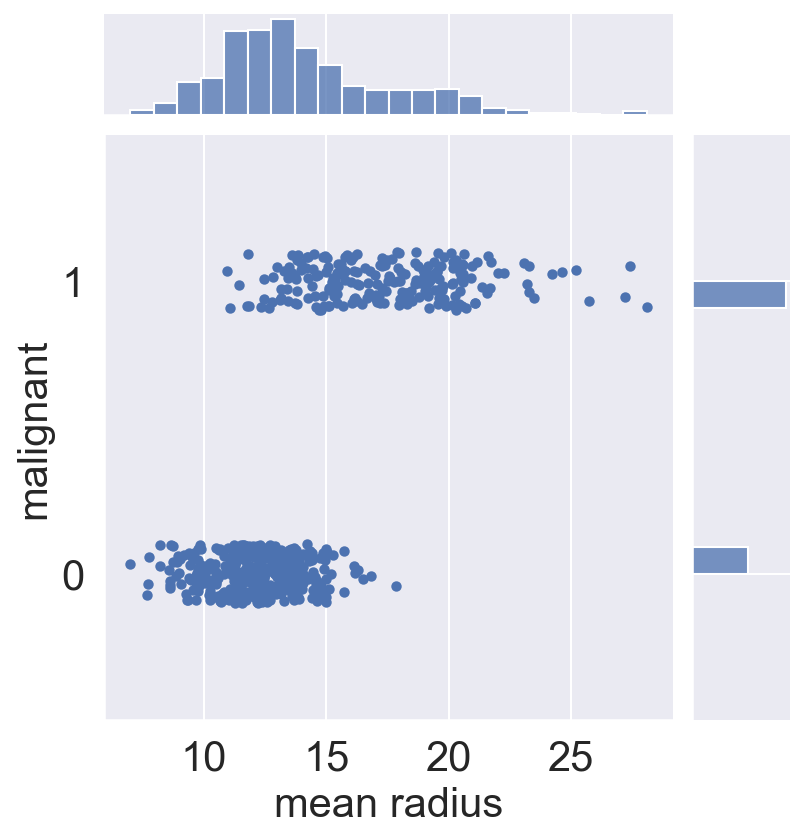

In [15]:
# manual to allow for jitter
g = sns.JointGrid(data = data, x = "mean radius", y = "malignant")
g.plot_marginals(sns.histplot)
g.plot_joint(sns.stripplot,
             orient='h', order=[1, 0],
             color=sns.color_palette()[0])
(g.ax_joint).set_xticks([10, 15, 20, 25])
#savefig("jitter")
plt.show()

Perhaps a better way to visualize the data is using stacked histograms.

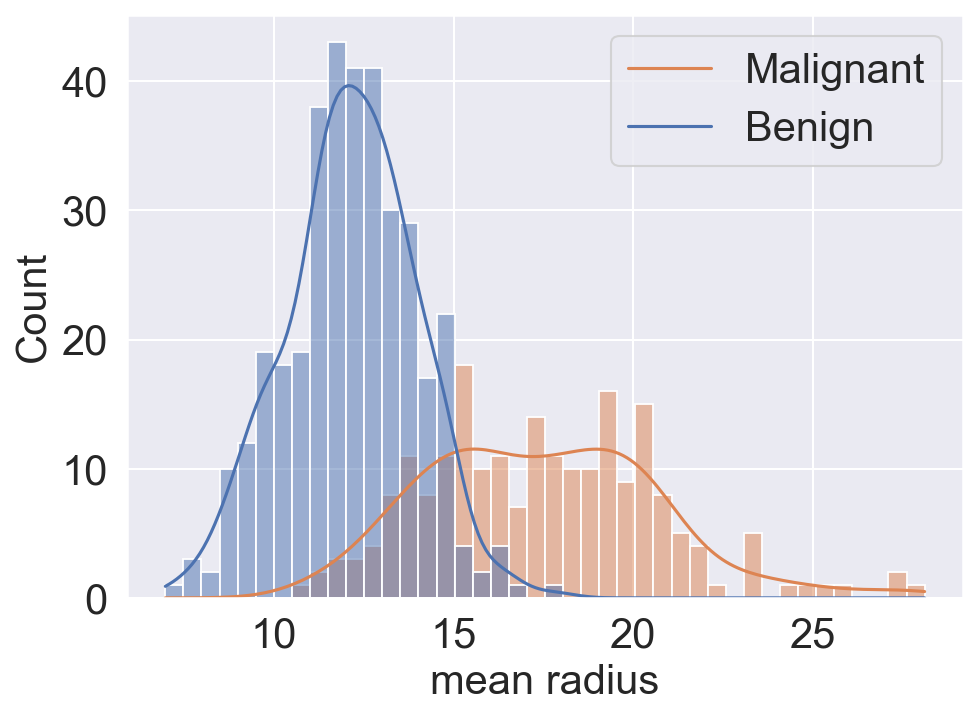

In [17]:
sns.histplot(data = data, x = "mean radius", hue = "malignant",
             binwidth=0.5,
             kde=True);
plt.legend(labels=["Malignant", "Benign"])

**Question:** Looking at the above histograms could you describe a rule to predict whether or a cell is malignant?


### Preparing the Data Train-Test Split

Always split your data into training and Testing groups.  

In [20]:
from sklearn.model_selection import train_test_split
data_tr_val, data_te = train_test_split(data, test_size=0.20, random_state=42)
data_tr, data_val = train_test_split(data_tr_val, test_size=0.20, random_state=101)
data_tr.reset_index(inplace=True, drop=True)
data_te.reset_index(inplace=True, drop=True)
print("Training Data Size: ", len(data_tr))
print("Validation Data Size: ", len(data_val))
print("Test Data Size: ", len(data_te))

# X, Y are training data
X = data_tr[['mean radius']].to_numpy()
Y = data_tr['malignant'].to_numpy()

Training Data Size:  364
Validation Data Size:  91
Test Data Size:  114


Creating the `X` and `Y` matrices for the training data:

In [22]:
X = data_tr[['mean radius']].to_numpy()
Y = data_tr['malignant'].to_numpy()

# Choosing a Model


---

<br/>


## Why Not Use Least-Squares Linear Regression?

_"I suppose it is tempting, if the only tool you have is a hammer, to treat everything as if it were a nail."_ -  Abraham Maslow The Psychology of Science

We would like to predict whether the tumor is malignant from the size of the tumor.  We have encoded whether a tumor is malignant or benign as 1 or 0.  Those are numbers that we could pretend are continuous and directly apply least squares regression.  Why not start there?

In the following, we use Seaborn's simple linear regression fit. Note, we will not use any regularization since this is a really simple one-dimensional model with a comparatively large training dataset. 

How well does our model fit the data?

(-0.5, 1.5)

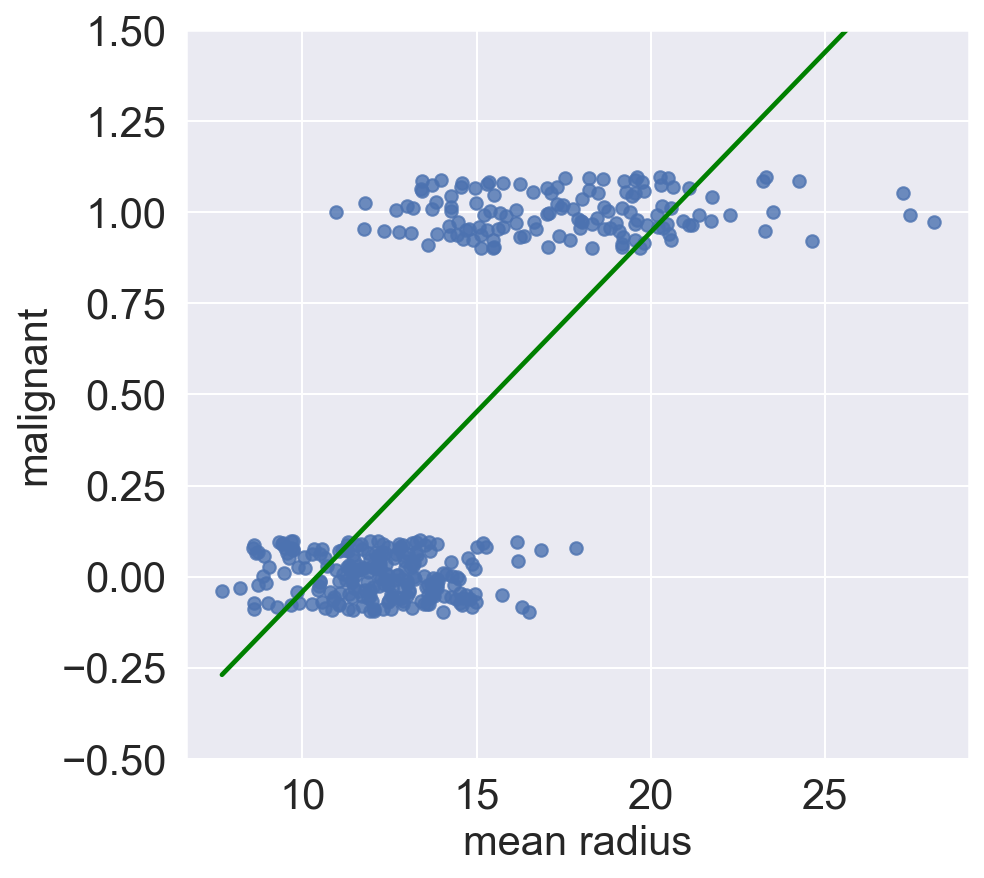

In [26]:
plt.figure(figsize=(6, 6))
sns.regplot(data=data_tr, x='mean radius', y='malignant', 
              y_jitter = 0.1, 
              ci=False,
              line_kws={'color':'green'});
plt.ylim((-0.5, 1.5))
#savefig("least_squares")

<br/><br/>

Among various issues (such as the fit being hard to interpret), the OLS model is very sensitive to outliers.

Suppose we had a training datapoint with extra-large $x$. See how least squares linear regression overfits to the large outlier point. It completely changes the classification for a large set of our datapoints.

In [28]:
data_out = data_tr[['mean radius', 'malignant']].copy()

# replace a datapont with a big outlier
# (mean radius = 120, malignant = 1) 
data_out.iloc[0, :2] = [120, 1]
data_out.head()

lin_reg = LinearRegression()
lin_reg.fit(data_tr[['mean radius']], data_tr['malignant'])
m, b = lin_reg.coef_[0], lin_reg.intercept_
vert_x = (0.5 - b)/m

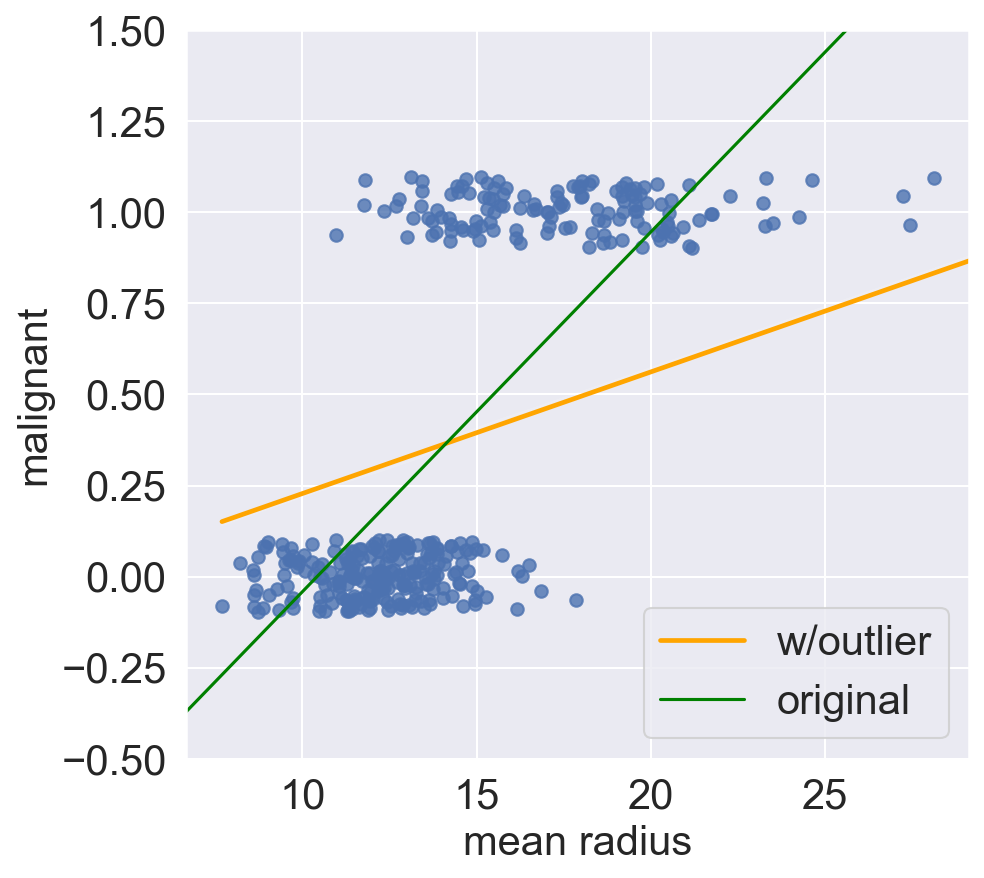

In [29]:
plt.figure(figsize=(6, 6))
sns.regplot(data = data_out, x = "mean radius", y = "malignant", 
              y_jitter = 0.1, 
              ci=False,
              line_kws={'color':'orange', 'label': 'w/outlier'},
           );
x_datapoints = np.array(plt.xlim())
plt.plot(x_datapoints, (x_datapoints)*m + b, color='green', label='original')
plt.ylim((-0.5, 1.5))
plt.xlim((6.67005, 29.13095))
plt.legend()
#savefig("outlier")

# Graph of Averages

We need a better model. Let's try and replicate the **graph of averages** for Simple Linear Regression ([textbook](https://inferentialthinking.com/chapters/08/1/Applying_a_Function_to_a_Column.html#example-prediction)), but now for Classification instead. Recall, we
- binned the $x$ axis.
- took the average $y$ value for each bin on the $x$ axis.

We will do the same thing here, albeit with slightly different code. Here, we will formally partition the $x$-axis into 20 bins.

In [31]:
# partition the training x data
bins = pd.cut(data_tr['mean radius'], 20) # Series of bin labels
data_tr['bin midpoint'] = [(b.left + b.right) / 2 for b in bins]

# then, get the average y per bin
avg_y_by_bin = data_tr.groupby('bin midpoint')['malignant'].mean()
avg_y_by_bin

bin midpoint
8.1915     0.000000
9.2225     0.000000
10.2435    0.000000
11.2645    0.043478
12.2855    0.070175
13.3065    0.163636
14.3275    0.394737
15.3485    0.689655
16.3695    0.615385
17.3900    0.928571
18.4105    1.000000
19.4315    1.000000
20.4525    1.000000
21.4735    1.000000
22.4945    1.000000
23.5155    1.000000
24.5365    1.000000
27.5995    1.000000
Name: malignant, dtype: float64

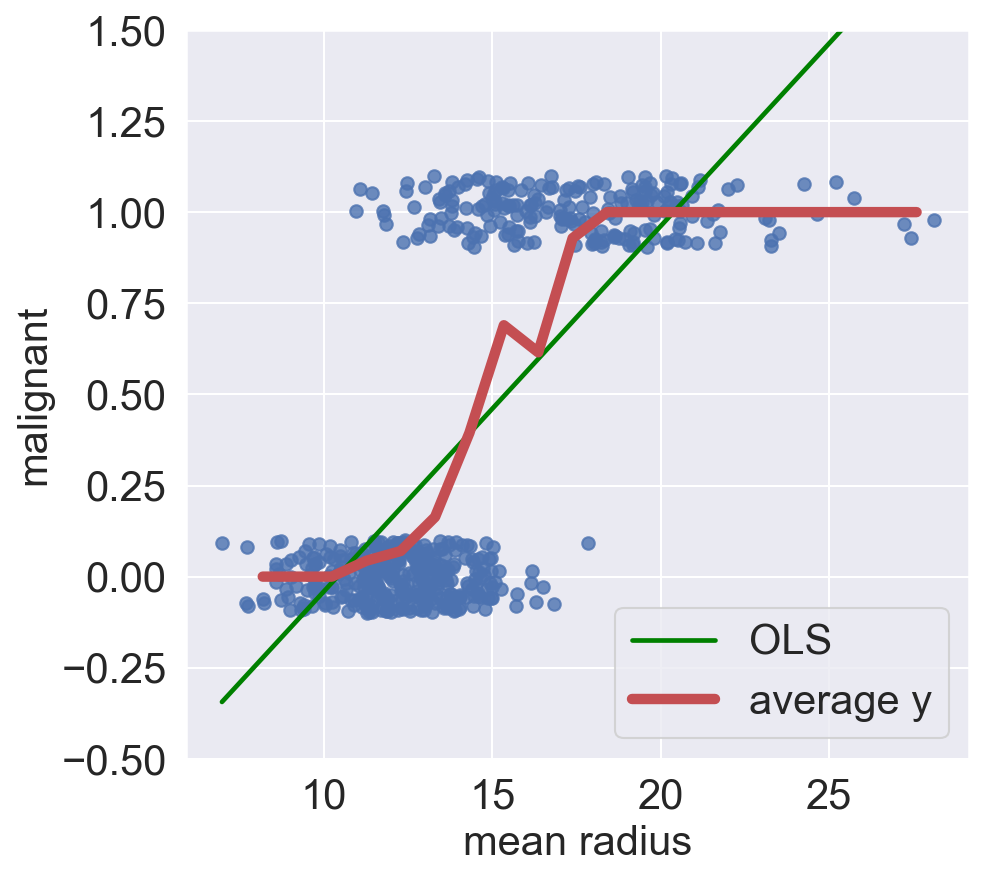

In [32]:
plt.figure(figsize=(6,6))
sns.regplot(data = data, x = "mean radius", y = "malignant", 
              y_jitter = 0.1, 
              ci=False,
              line_kws={'color':'green', 'label': 'OLS'},
           );

plt.plot(avg_y_by_bin, 'r', linewidth = 5, label='average y');
plt.ylim((-0.5, 1.5))
plt.legend()
#("graph_of_averages")

It seems like our red graph of averages does a much better job at matching the data than our simple linear regression line.

**Q**: **What is this graph of averages plotting?**

For a given $x$, suppose its bin has the current $y$ as follows, producing the following average $y$:

$$ [0, 0, 1, 1, 1, 1, 0, 0, 0, 0] \rightarrow 0.4 $$

For this bin, the average y value is:
* A number between 0 and 1.
* The frequency of 1’s in the bin.

The average y for a bin is therefore a **probability**!!

$$P(Y = 1 | x) = \frac{\text{# (y == 1) in bin}}{\text{# datapoints in bin
}}$$

**Logistic regression aims to model the probability of an observation belonging to class 1, given some set of features.**

<br/><br/>

Logistic Regression is what we call a generalized linear model.
* Non-linear transformation of a linear model.
* So parameters are still a linear combination of x!

In this notebook, we'll do Step 1 of deriving the logistic model.

## 1. Transform the y-axis non-linearly until the “S curve” looks linear.

First let's rename our variables from earlier so that we simplify some notation.

<Axes: xlabel='x', ylabel='p'>

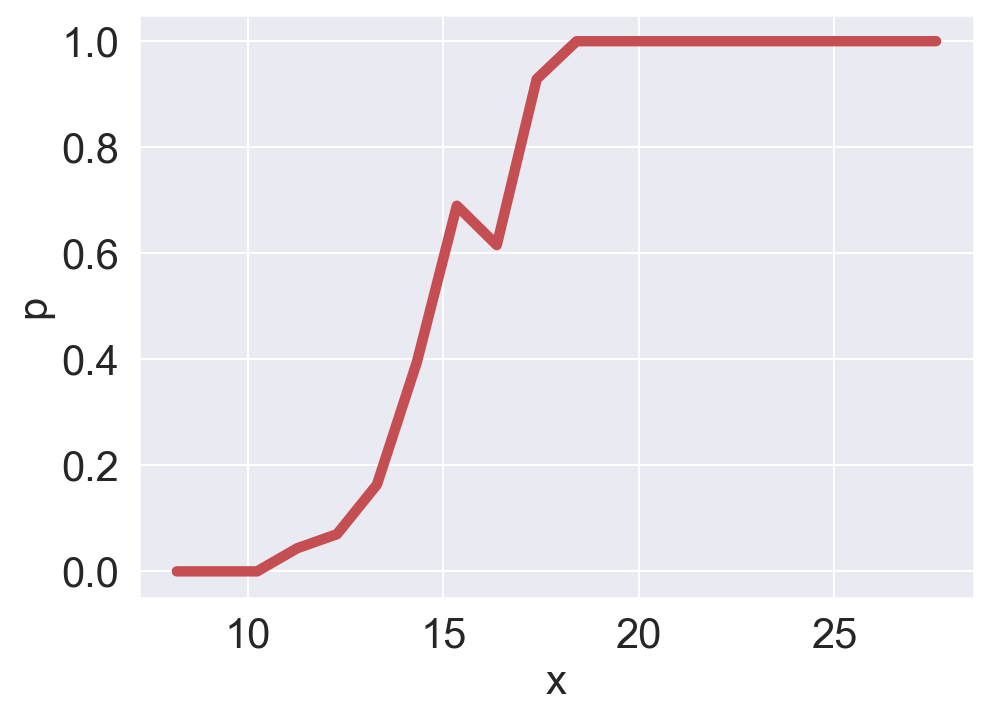

In [36]:
transform_df = pd.DataFrame({"x": avg_y_by_bin.index,
                        "p": avg_y_by_bin.values})

sns.lineplot(data=transform_df, x='x', y='p', color='r', linewidth = 5)
#savefig('transform_1')

<br/>

The **odds** of an event are defined as the probability that it happens divided by the probability that it doesn't happen.

If some event happens with probability $p$, then 
<br/>

$$\text{odds}(p) = \frac{p}{1-p}$$

Let's compute the odds of of our probabilities.

If we plot these odds, they look exponential:

<Axes: xlabel='x', ylabel='odds'>

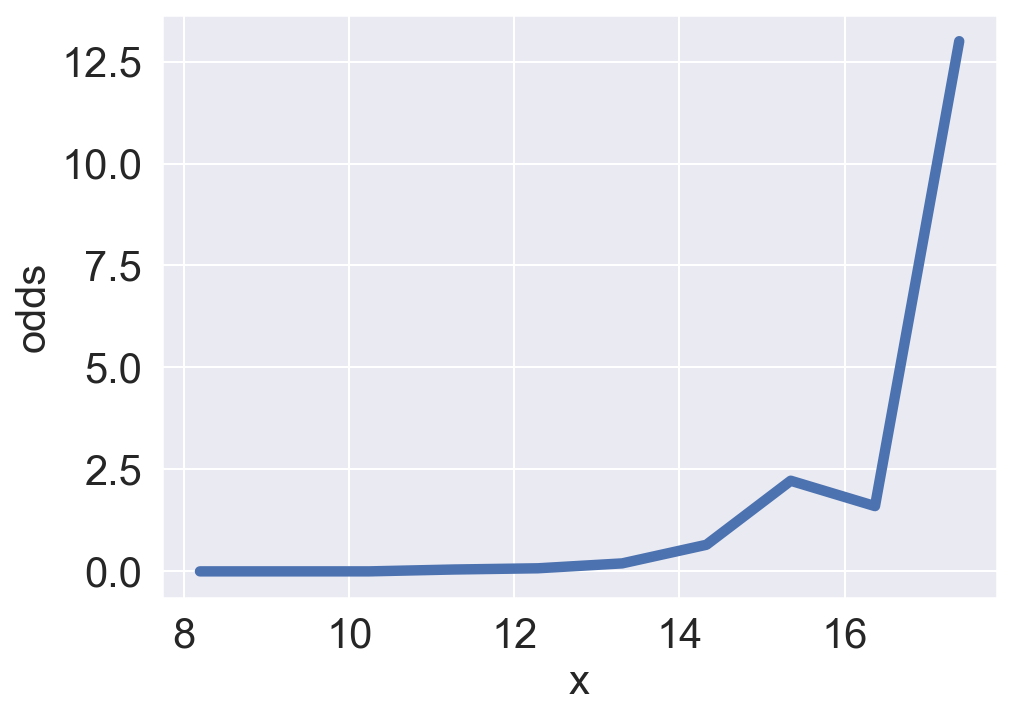

In [38]:
transform_df['odds'] = transform_df['p'] / (1 - transform_df['p'])

sns.lineplot(data=transform_df,
             x='x', y='odds', linewidth = 5)
#savefig("transform_2")

But if we take the log of these odds:

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



<Axes: xlabel='x', ylabel='log-odds'>

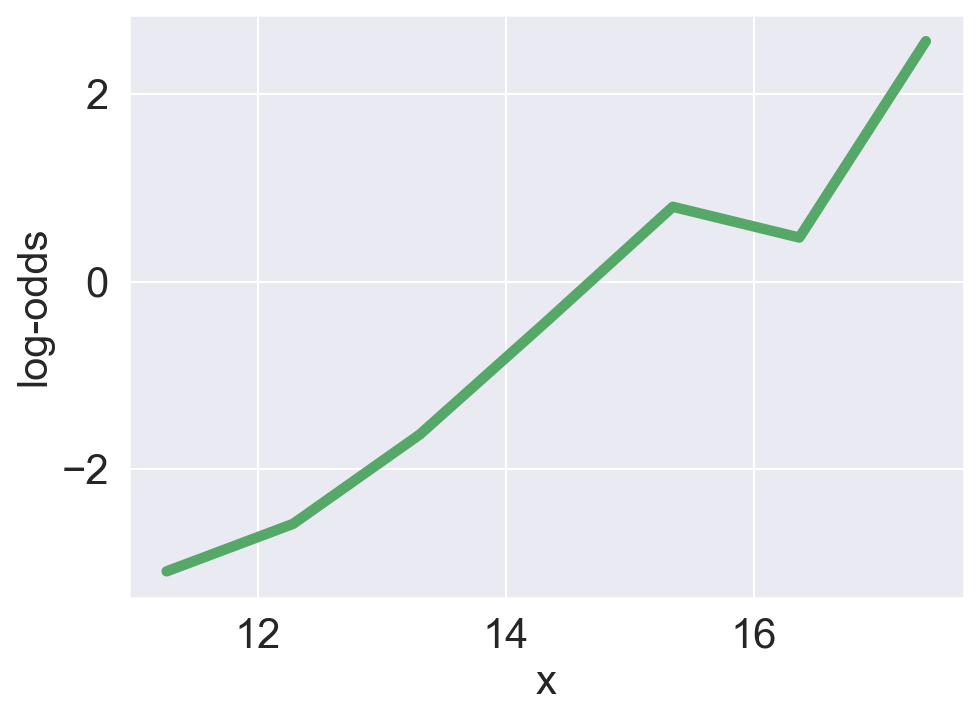

In [40]:
transform_df['log-odds'] = np.log(transform_df['odds'])

sns.lineplot(data=transform_df,
             x='x', y='log-odds',
             color='g', linewidth = 5)
#savefig("transform_3")

## 2. Then, use math to invert all transformations.

(This portion is left to the lecture slides.)

We noticed that the **log-odds grows linearly with $x$**. 

In the lecture slides, we formalize what this means, and how this allows us to arrive at the `logistic` (a type of sigmoid) function above.

## The Logistic Function

In the slides, we show that our model is

$$P(Y = 1 | x) = f(x^T \theta)$$

where $$f(z) = \frac{1}{1 + e^{-z}}$$

Let's explore the shape of the logistic function

In [43]:
# the logistic function
# known as the sigmoid function in ML
def sigma(z):
    return 1 / (1 + np.exp(-z))

We'll explain how we found the optimal parameter fit by the end of lecture, but for now hopefully you're convinced that the S-curve is actually a logistic function.

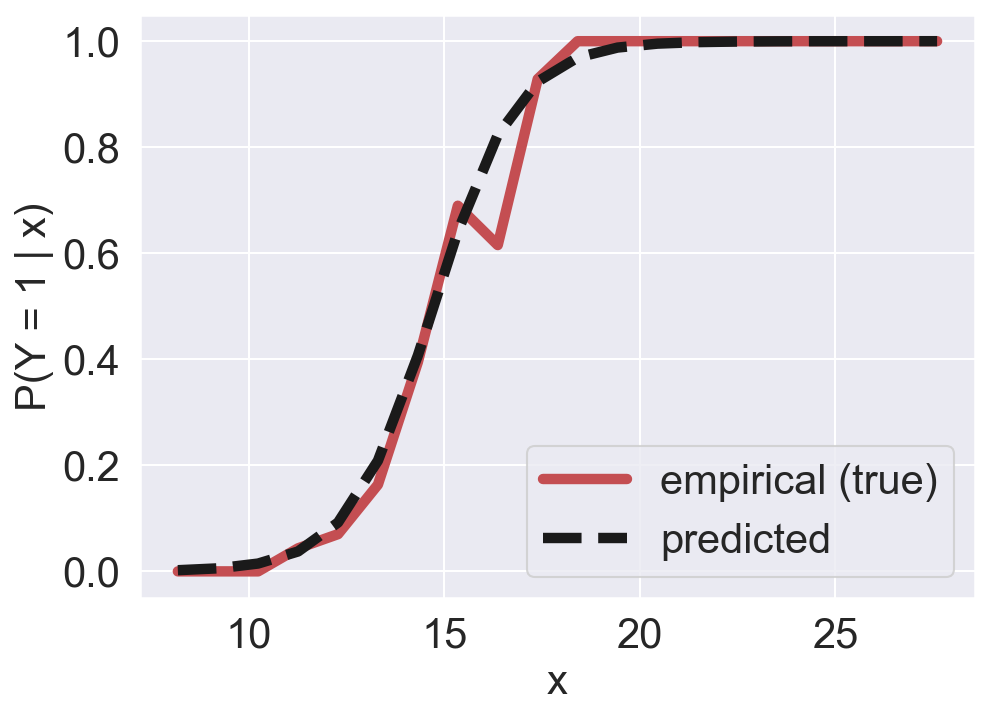

In [45]:
# We'll show where these values for theta comes from later in this notebook
theta_0 = -13.8
theta_1 = 0.937

sns.lineplot(data=transform_df, x='x', y='p', color='r',
             linewidth = 5, label='empirical (true)')
x = transform_df['x']
pred_p = sigma(theta_0 + theta_1 * x)
plt.plot(x, pred_p, 'k--', linewidth = 5, label='predicted');
plt.xlabel('x');
plt.ylabel('P(Y = 1 | x)')
plt.legend()
#savefig("overlay")

Let's explore the shape of $f(\theta_0 + \theta_1x)$, for different values of $\theta_0, \theta_1$. There's quite a bit going on here, so let's use `plotly`.

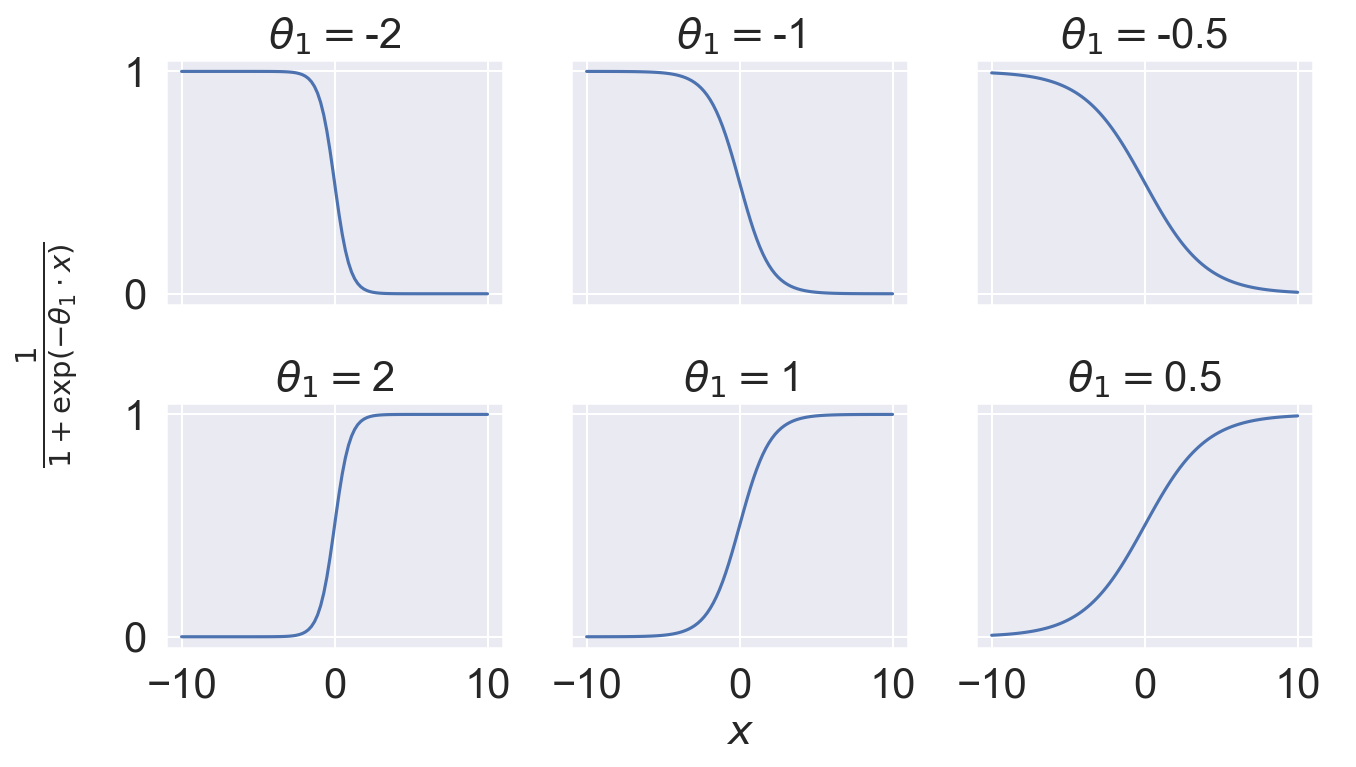

In [47]:
def flatten(li): 
    return [item for sub in li for item in sub]

bs = [-2, -1, -0.5, 2, 1, 0.5]
xs = np.linspace(-10, 10, 100)

fig, axes = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 6))
for ax, b in zip(flatten(axes), bs):
    ys = sigma(xs * b)
    ax.plot(xs, ys)
    ax.set_title(r'$ \theta_1 = $' + str(b))

# add a big axes, hide frame
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axes
plt.tick_params(labelcolor='none', top=False, bottom=False,
                left=False, right=False)
plt.grid(False)
plt.xlabel('$x$')
plt.ylabel(r'$ \frac{1}{1+\exp(-\theta_1 \cdot x)} $')
plt.tight_layout()
#savefig('sigmoids.png')

# Choosing a Loss Function

## Logistic Regression with Squared Loss

We've chosen a model. It's now time to choose a loss function. Why not squared loss?

In [50]:
def mse_loss_train_nobias(theta):
    x = data_tr['mean radius']
    y_obs = data_tr['malignant']
    y_hat = sigma(x * theta)
    return np.mean((y_hat - y_obs) ** 2)  

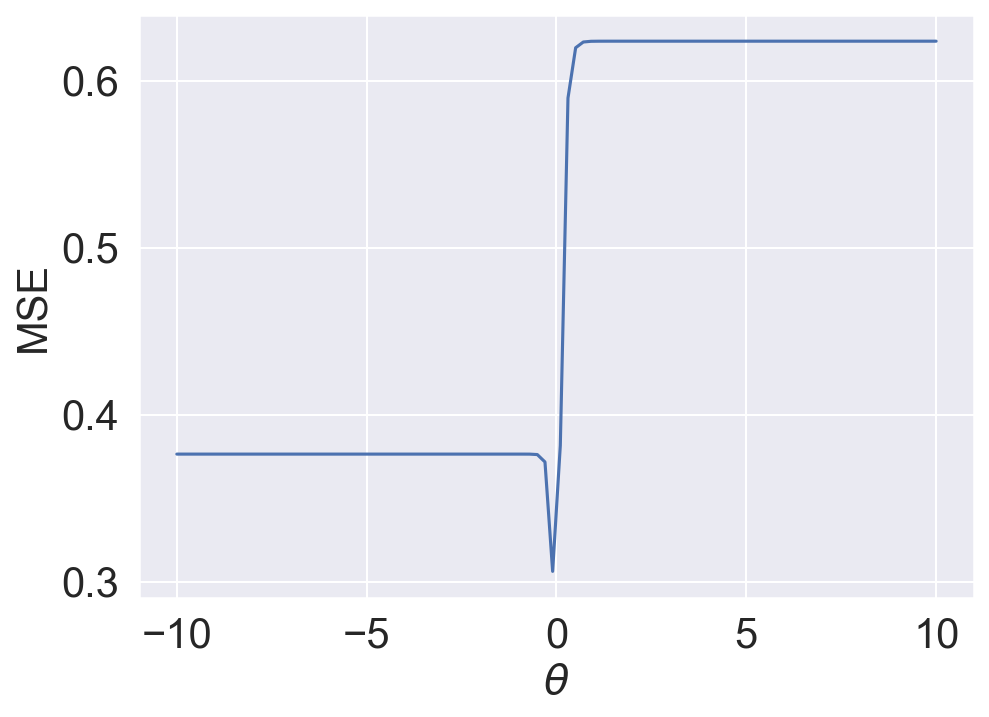

In [51]:
thetas = np.linspace(-10, 10, 100)
plt.plot(thetas, [mse_loss_train_nobias(theta) for theta in thetas])
plt.ylabel('MSE')
plt.xlabel(r'$\theta$');

<br/><br/>

What????

## Toy Dataset: L2 Loss

Consider this manufactured dataset.

In [53]:
toy_df = pd.DataFrame({
        "x": [-4, -2, -0.5, 1, 3, 5],
        "y": [0, 0, 1, 0, 1, 1]
        #"x": [-9.5, -5.8, -4.0, 8.7, 12.0],
        #"y": [1, 0, 0, 1, 0]
    
})
toy_df.sort_values("x")

,x,y
0,-4.0,0
1,-2.0,0
2,-0.5,1
3,1.0,0
4,3.0,1
5,5.0,1


Text(0.5, 1.0, 'Toy classification data')

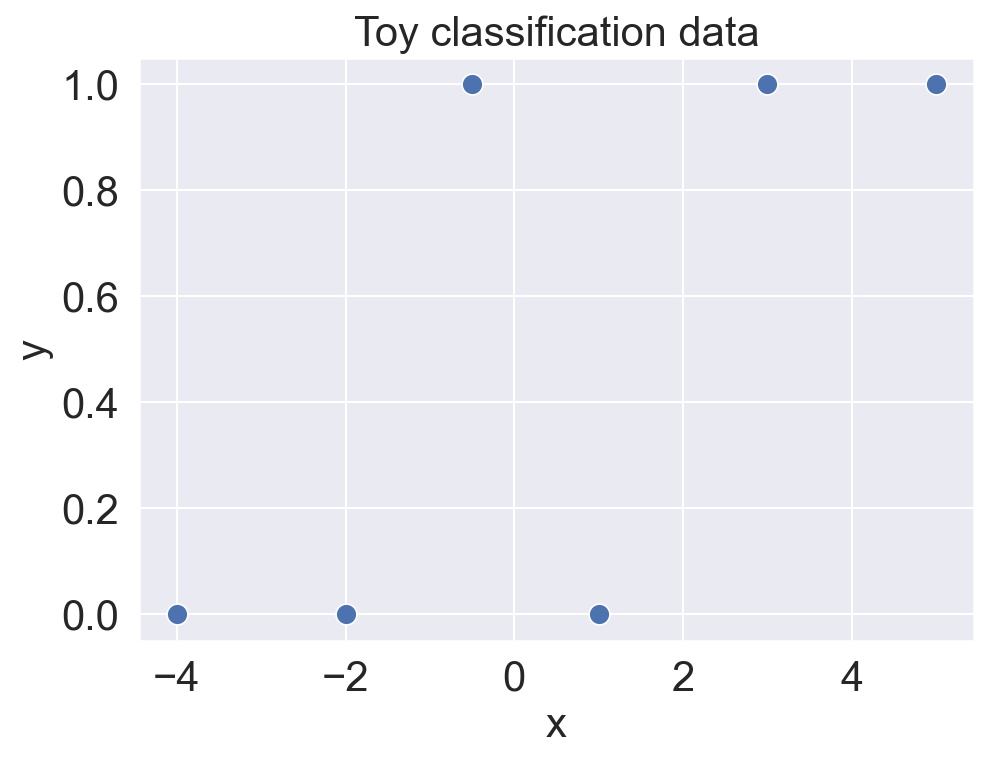

In [54]:
sns.scatterplot(data=toy_df, x='x', y='y', s=100)
plt.title("Toy classification data")


Let's plot the loss surface for this toy data using squared loss with the model $\hat{p} = f(\theta x)$, where $f$ is the logistic function. We don't include an intercept term, so $\theta$ and $x$ are both scalars.

$\hat{P}_{\theta}(Y=1 | x) = \frac{1}{1+e^{-\theta x}}$

$R(\theta) = \frac{1}{n} \sum \limits_{i=1}^n (y_i - \frac{1}{1+e^{-\theta x_i}})^2$

Text(0, 0.5, 'R($\\theta$)=MSE')

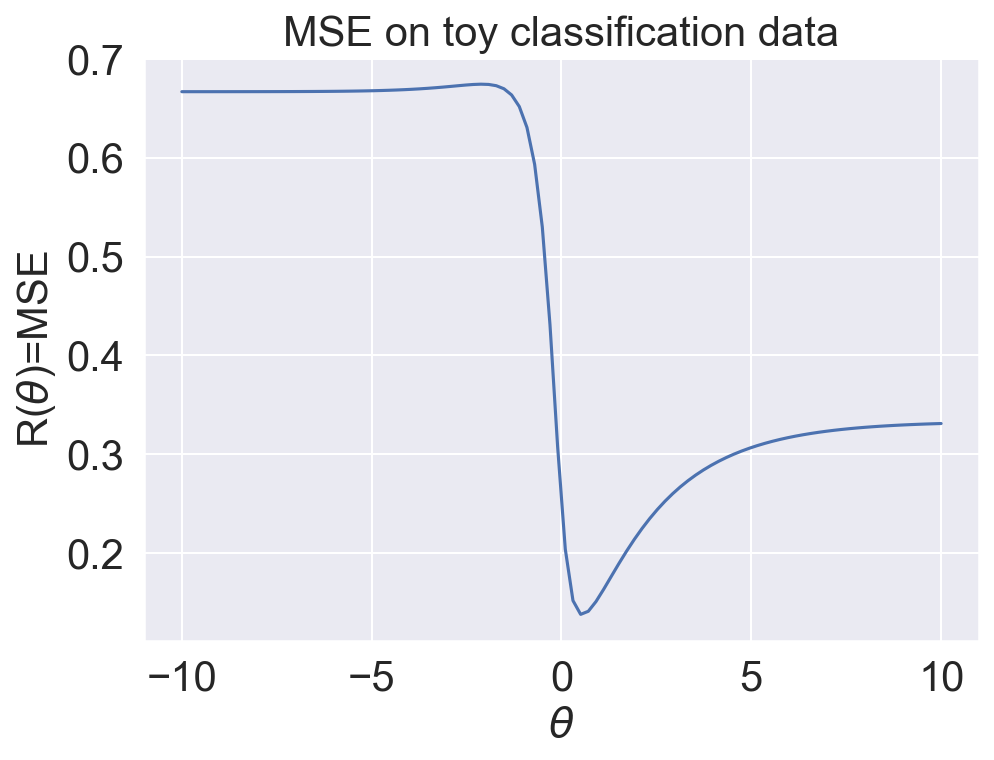

In [56]:
def mse_loss_toy_nobias(theta):
    p_hat = sigma(toy_df['x'] * theta)
    return np.mean((toy_df['y'] - p_hat)**2)

thetas = np.linspace(-10, 10, 100)
plt.plot(thetas, [mse_loss_toy_nobias(theta) for theta in thetas])
plt.title("MSE on toy classification data");
plt.xlabel(r'$\theta$')
plt.ylabel(r'R($\theta$)=MSE')


This loss surface is not convex! Depending on where we start our optimization search, we'll end up with different results. Let's explore with `scipy.optimize.minimize`.

In [58]:
best_theta = minimize(mse_loss_toy_nobias, x0 = 0)["x"][0]
best_theta

0.5446601825581691

Remember, our 1-D model with no intercept is $\hat{p} = f(\theta x)$.

Text(0.5, 1.0, '$\\hat{\\theta} = $0.5447')

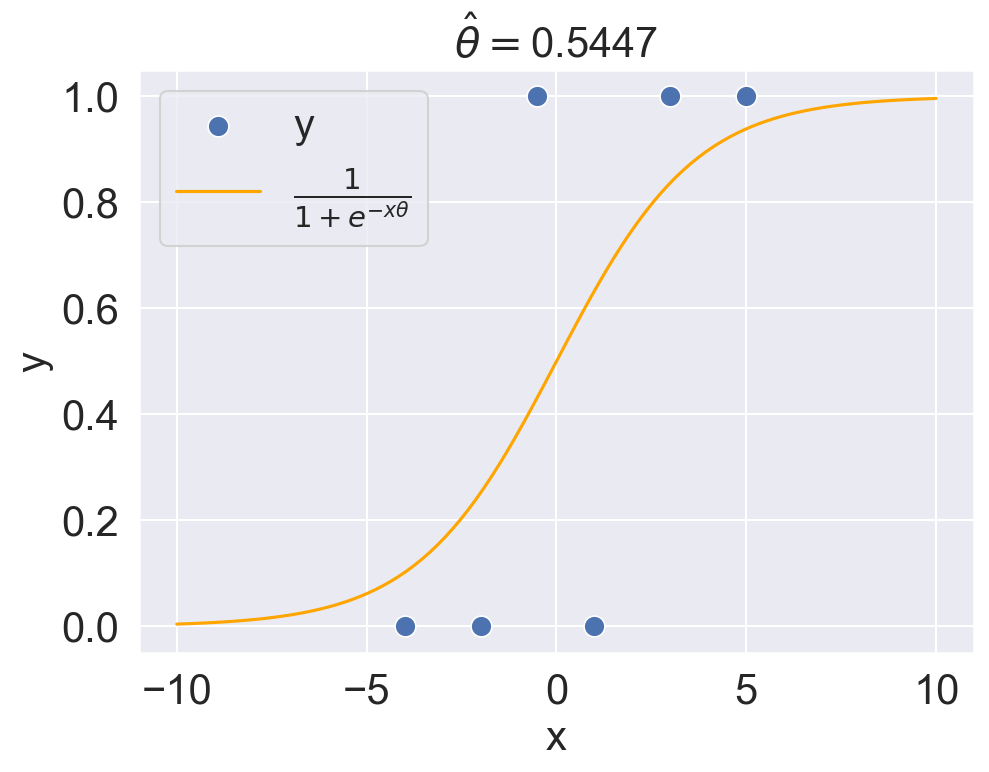

In [60]:
sns.scatterplot(data=toy_df, x='x', y='y', s=100, label='y')
xs = np.linspace(-10, 10, 100)
plt.plot(xs, sigma(xs * best_theta), color='orange', label=r'$\frac{1}{1+e^{-x \theta}}$')
plt.xlabel('x')
plt.legend()
plt.title(r'$\hat{\theta} = $' + f"{best_theta:.4}")


<br/>
Let's try another starting point for minimizing theta.

In [62]:
best_theta_2 = minimize(mse_loss_toy_nobias, x0 = -5)["x"][0]
best_theta_2

-10.343653061026611

Uhhh, looks like the optimizer got stuck.

Text(0.5, 1.0, '$\\hat{\\theta} = $-10.34')

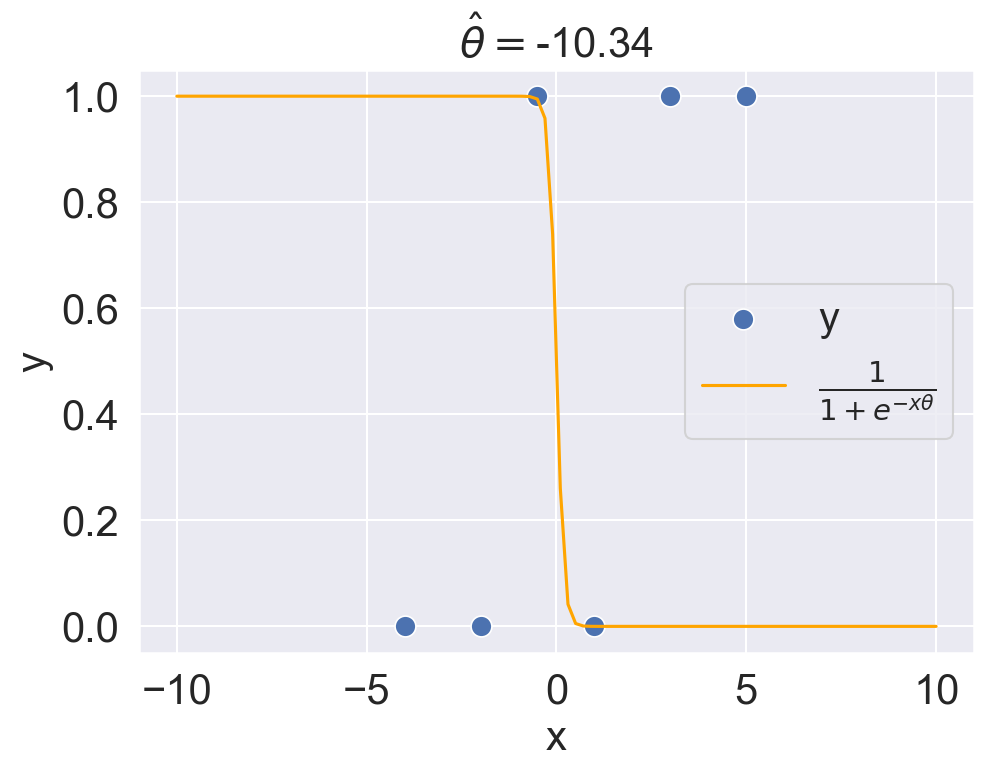

In [64]:
sns.scatterplot(data=toy_df, x='x', y='y', s=100, label='y')
xs = np.linspace(-10, 10, 100)
plt.plot(xs, sigma(xs * best_theta_2), color='orange', label=r'$\frac{1}{1+e^{-x \theta}}$')
plt.xlabel('x')
plt.legend()
plt.title(r'$\hat{\theta} = $' + f"{best_theta_2:.4}")


Not only is it not convex, leading to the weird issues above, but squared loss just isn't well-suited for a probability task. Since $\hat{p}_i$ is between 0 and 1, and $y_i$ is either 0 or 1, the squared loss for a single point $(y_i - \hat{p}_i)^2$ is bounded between 0 and 1.

What this means in practice: even if our prediction is terrible, the squared loss is never that large.

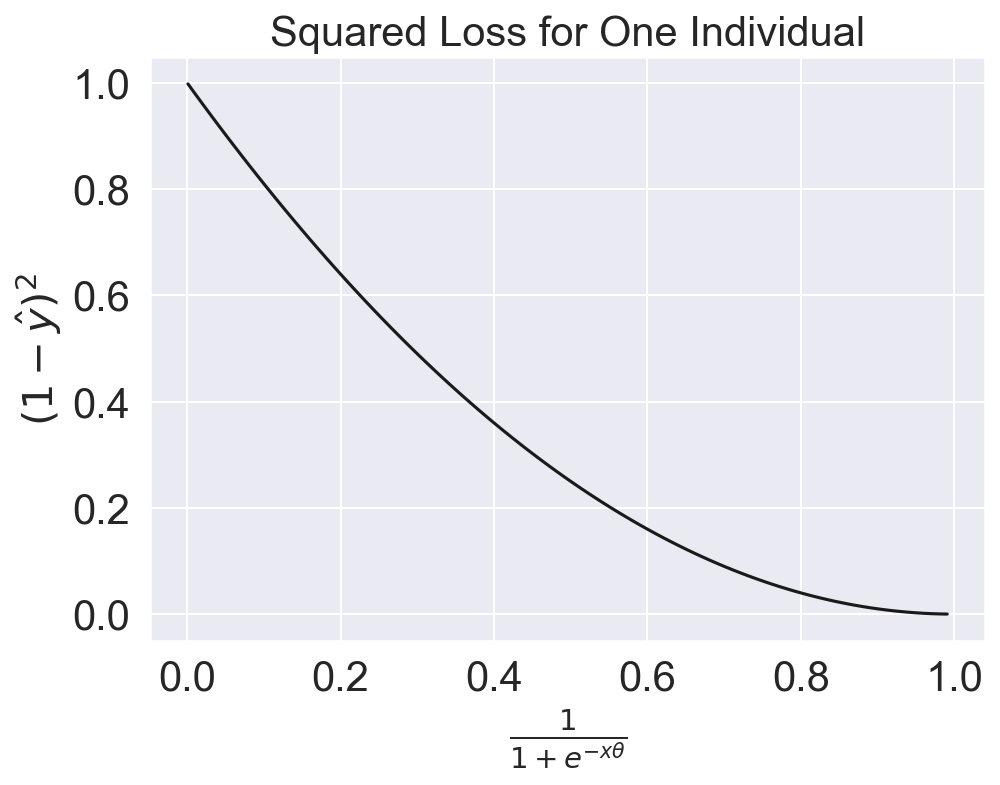

In [66]:
p_hat = np.arange(0.001, 0.999, 0.01)
loss = (1 - p_hat)**2
plt.plot(p_hat, loss, color='k')
plt.xlabel(r'$\frac{1}{1+e^{-x \theta}}$')
plt.ylabel(r'$(1 - \hat{y})^2$')
plt.title('Squared Loss for One Individual');


## Motivating Cross-Entropy Loss

Let's look at a new loss, called the log loss, for when our true observation is 1.

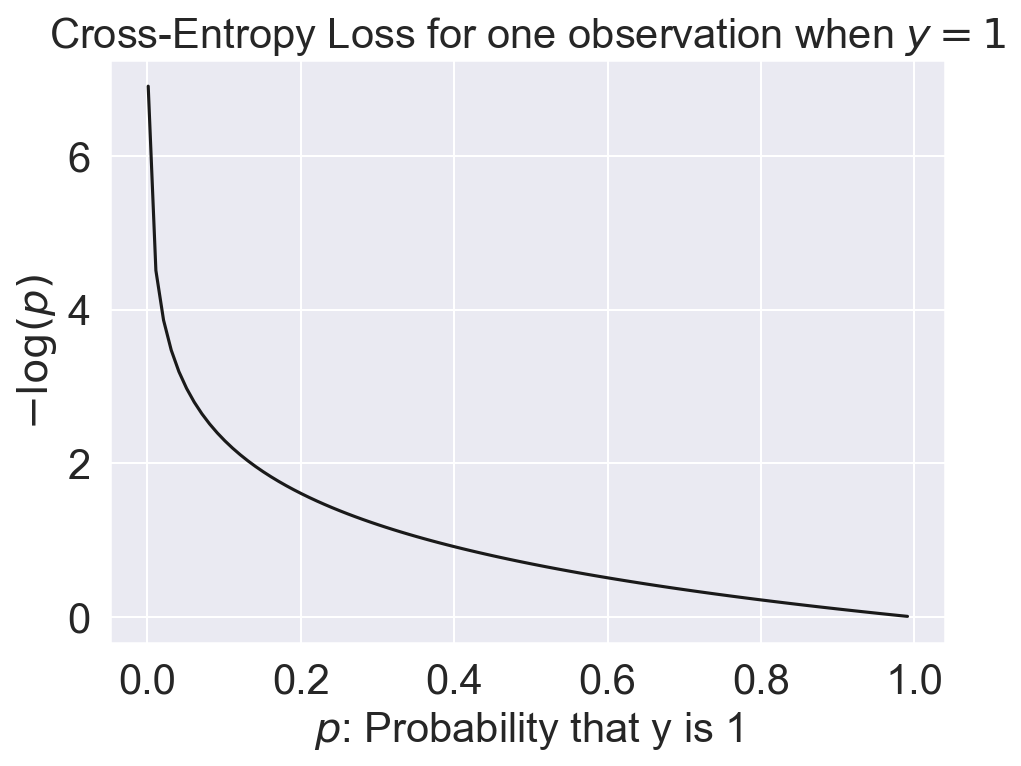

In [69]:
p_hat = np.arange(0.001, 0.999, 0.01)
loss = -np.log(p_hat)
plt.plot(p_hat, loss, color='k')
plt.xlabel('$p$: Probability that y is 1')
plt.ylabel('$-\log(p)$')
plt.title('Cross-Entropy Loss for one observation when $y = 1$');
#savefig("entropy_y1")

We can see that this penalizes wrong predictions far more than squared loss does.

How to read this plot: Suppose the observation we're trying to predict is actually in class 1. If our model gives an 80% chance of being in class 1, the loss is relatively small (around 0.25). 

If we give only a 40% of being in class 1, the loss is larger (around 1).

If we give only a 5% chance of being in class 1, the loss is 3.

And if we give a 0% chance of being in class 1, the loss is infinite.

What about when the true observation is 0?

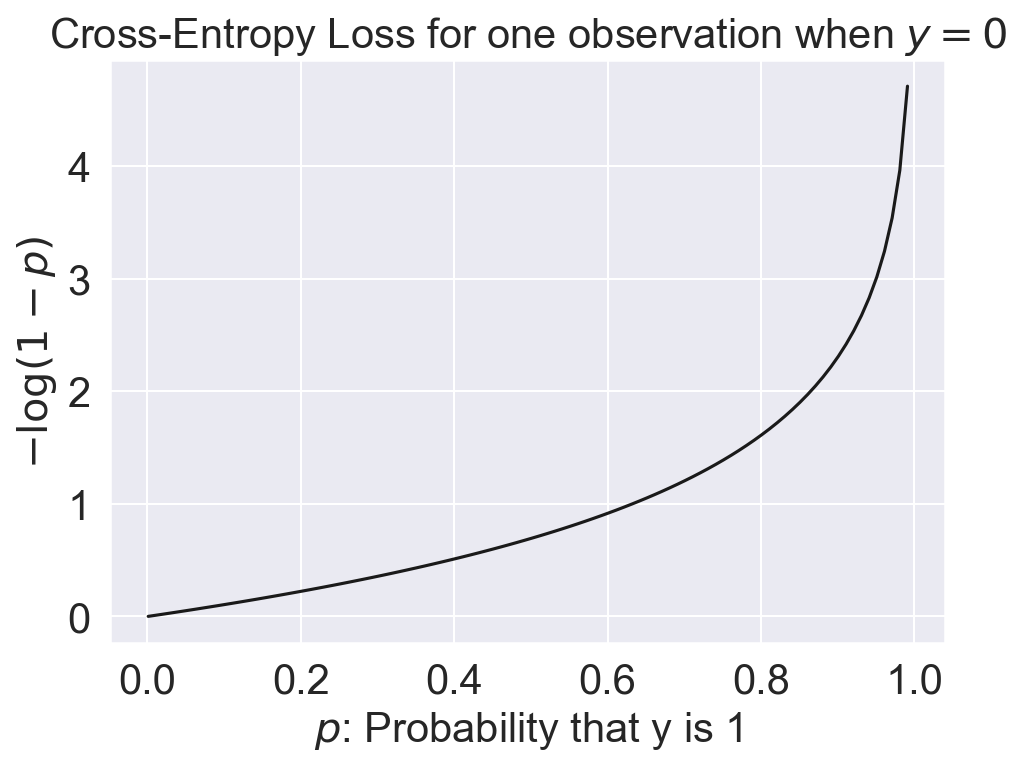

In [71]:
p_hat = np.arange(0.001, 0.999, 0.01)
loss = -np.log(1 - p_hat)
plt.plot(p_hat, loss, color='k')
plt.xlabel('$p$: Probability that y is 1')
plt.ylabel('$-\log(1 - p)$')
plt.title('Cross-Entropy Loss for one observation when $y = 0$');
#savefig("entropy_y0")

Much of the formal derivation is in the slides. 




But the equation for cross-entropy loss for a single observation is

$$\textrm{loss} = -y \log(\hat{y}) - (1-y)\log(1-\hat{y})$$


$$\hat{y} = \frac{1}{1+e^{-x_i^T \theta}}$$

where $$x_i^T \theta = \theta_0+\theta_1x_{i1}+\theta_2x_{i2}+...\theta_px_{ip} $$



For us, since $\hat{y} = \frac{1}{1+e^{-x^T \theta}}$, the expression for average cross-entropy loss is

$$R(\theta) = -\frac{1}{n} \sum_{i = 1}^n \big(y_i \log \left(\frac{1}{1+e^{-x_i^T {\theta}}}\right) + (1 - y_i) \log \left(1 - \frac{1}{1+e^{-x_i^T \theta}}\right) \big)$$

where $x_i$ is the $i$th feature vector

Let's look at the loss surface for average cross-entropy loss, on our toy data from before.

In [73]:
def cross_entropy(y, phat):
    return - y * np.log(phat) - (1 - y) * np.log(1 - phat)

In [74]:
def mce_loss_toy_nobias(theta):
    p_hat = sigma(toy_df['x'] * theta)
    return np.mean(cross_entropy(toy_df['y'], p_hat))

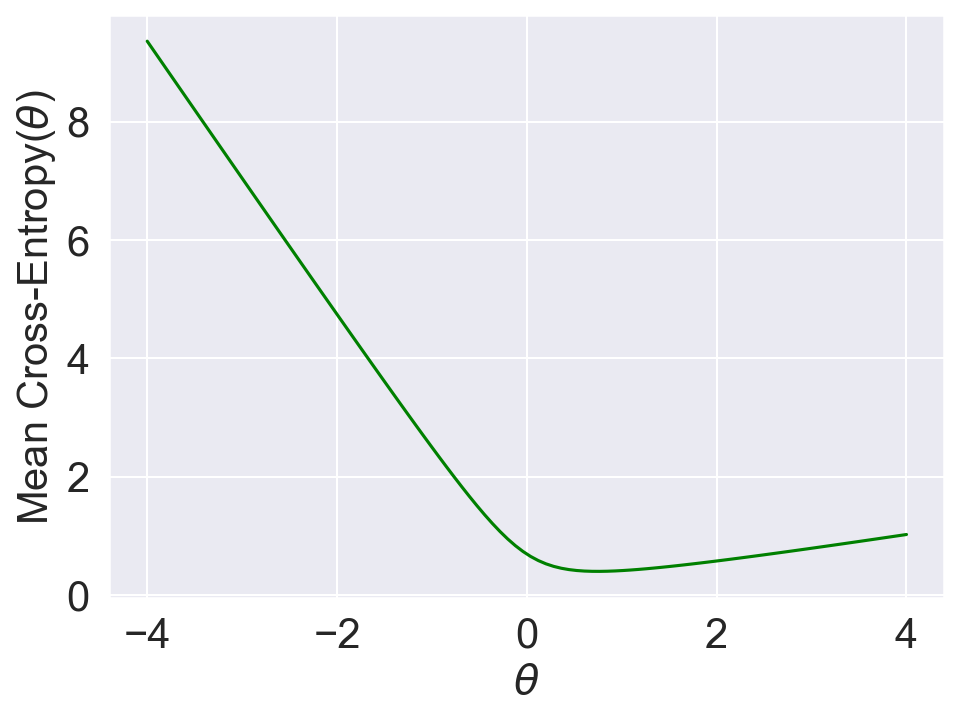

In [75]:
thetas = np.linspace(-4, 4, 100)
plt.plot(thetas, [mce_loss_toy_nobias(theta) for theta in thetas], color = 'green')
plt.ylabel(r'Mean Cross-Entropy($\theta$)')
plt.xlabel(r'$\theta$');
#savefig("toy_mce")

---

<br/><br/><br/>

# Fitting a Logistic Regression model with sklearn

Recall, we'd like to fit a logistic regression model to use the mean radius tumor size to predict whether or not the tumor is malignant.  Here is the training data:

In [78]:
X = data_tr[['mean radius']]
Y = data_tr['malignant']


In [79]:
Y.head()

0    0
1    1
2    0
3    1
4    1
Name: malignant, dtype: int64

Let's visualize the training data.

Tip: The seaborn function `stripplot` auto-plots jittered data by class.

Text(0, 0.5, 'y: class')

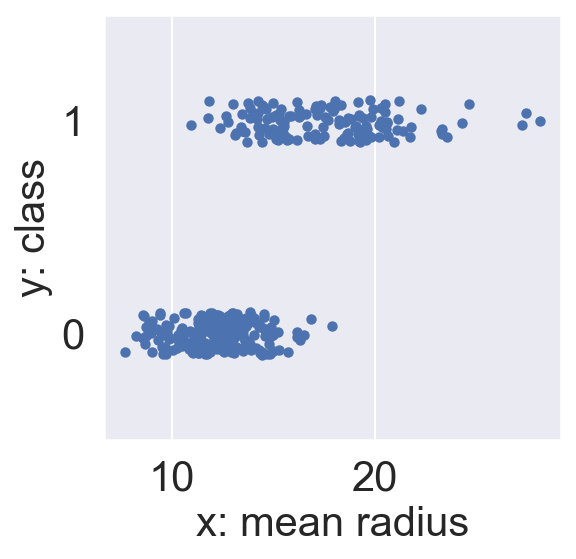

In [81]:
plt.figure(figsize=(3.5,3.5))
sns.stripplot(x=X.squeeze(), y=Y, 
              jitter = 0.1, orient='h');
plt.gca().invert_yaxis()
plt.xlabel('x: mean radius')
plt.ylabel('y: class')



### Fit

We'll fit a model with the mean radius feature (denoted as $x_1$) and an intercept. So our model is:

$$\hat{P}_{\theta} (Y = 1 | x) = \frac{1}{1+e^{-x^T \theta}} =\frac{1}{1+e^{-(\theta_0+\theta_1x_{1})}} $$


### sklearn
The `linear_model.LogisticRegression` model ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)) is what we want to use here. In order to recreate our specific model, there are a few parameters we need to set:
- `penalty = 'None'`: by default, `LogisticRegression` uses L2 regularization. This is generally a good idea (which we'll discuss in the video on Logistic regression and regularizatino), but is not needed in this case since our data is not linearly separable).
- `fit_intercept = True`: (this is the default) Our model has an intercept term.

<br/><br/>


In [83]:
from sklearn.linear_model import LogisticRegression

#initialize the model
model = LogisticRegression(penalty = None)

# fit the model
model.fit(X,Y) # X, Y are training data

LogisticRegression(penalty=None)

<br/>

Optimal $\theta_0, \theta_1$ from fitting our model:

In [85]:
model.intercept_, model.coef_

(array([-15.13424082]), array([[1.02213523]]))

<br/><br/>

### Prediction

<br/>

**Predict probabilities**: `scikit-learn` has a built-in `.predict_proba` method that allows us to get the predicted probabilities under our model. 

In [87]:
# Predict probability for a mean radius of 15:

model.predict_proba([[15]])


/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



array([[0.45071364, 0.54928636]])

To interpret this output, you can use the `.classes_` attribute, which stores our class labels.

In [89]:
model.classes_

array([0, 1])

In [90]:
X.head()

,mean radius
0,11.800
1,17.020
2,9.683
3,10.950
4,19.440


In [91]:
model.predict_proba(X)[:,1]

array([4.42329150e-02, 9.05723393e-01, 5.28856706e-03, 1.90424217e-02,
       9.91303224e-01, 1.78690916e-03, 9.95981784e-01, 1.82935209e-02,
       6.96135054e-02, 9.88799513e-01, 1.75081406e-03, 1.50070541e-01,
       4.05028414e-02, 9.70374976e-01, 4.29812579e-01, 7.91446165e-03,
       9.97433469e-01, 3.63873219e-01, 8.32920524e-02, 9.89669856e-01,
       2.72813565e-02, 5.20322674e-03, 7.23999719e-01, 5.58438270e-02,
       2.08390412e-02, 5.63852039e-02, 3.63521667e-02, 6.38862006e-02,
       9.52963809e-01, 5.96762475e-01, 6.04118979e-01, 6.45002178e-02,
       2.51598940e-01, 9.96333641e-01, 6.38862006e-02, 3.52931235e-02,
       2.27412402e-01, 1.02149509e-01, 4.49956849e-01, 4.82892180e-02,
       4.05028414e-02, 1.63799722e-02, 5.79432436e-01, 7.94587100e-01,
       5.69315127e-02, 5.36604627e-01, 1.54023833e-01, 9.99935742e-01,
       5.64418926e-01, 9.94491992e-01, 5.11870664e-02, 5.32095772e-02,
       8.21502957e-01, 9.97243631e-01, 9.42351341e-01, 9.62815581e-01,
      

<br/><br/>

Let's visualize these probabilities on our training dataset, `X` and `y`.

Text(0, 0.5, 'y: class')

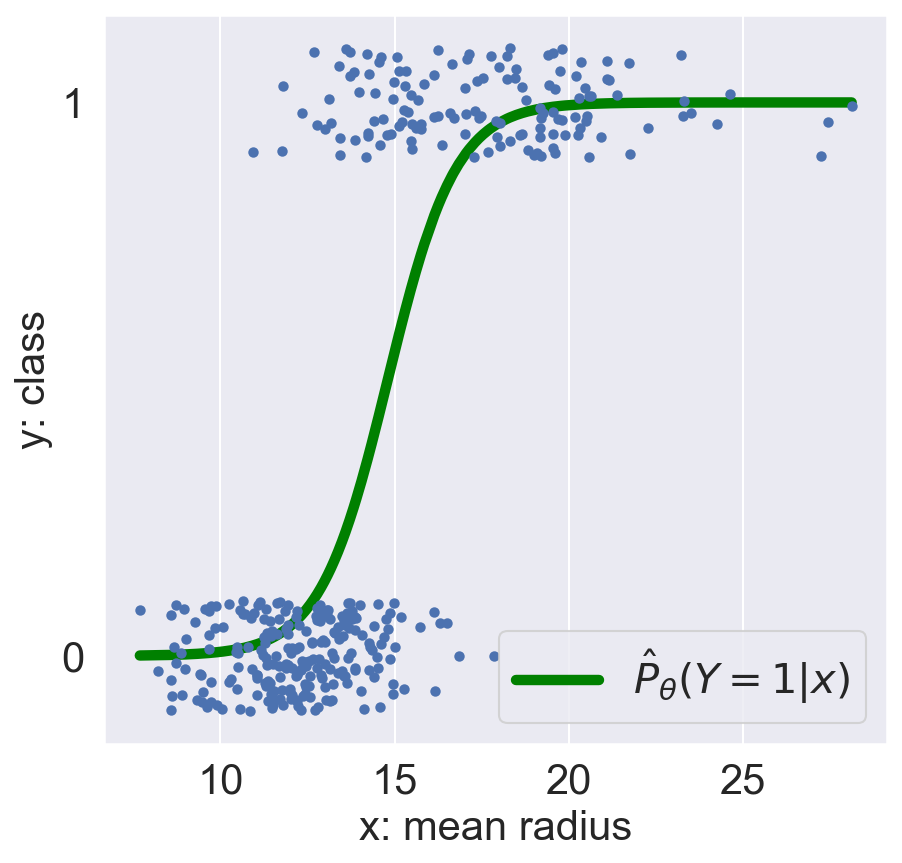

In [93]:
plt.figure(figsize=(6,6))
sns.stripplot(x=X.squeeze(), y=Y, 
              jitter = 0.1, orient='h');
sns.lineplot(x= X.squeeze(), y=model.predict_proba(X)[:,1],
             color='green', linewidth=5, label=r'$\hat{P}_{\theta}(Y = 1 | x)$')
plt.gca().invert_yaxis()
plt.xlabel('x: mean radius')
plt.ylabel('y: class')


<br/>

**Predict class labels**: By comparison, what does `.predict()` do?

It predicts 1 if the computed probability for class 1 is greater than 0.5, and 0 otherwise.

$$\text{classify}(x) = \begin{cases} 1, & P(Y = 1 | x) \geq 0.5 \\ 0, & \text{otherwise} \end{cases}$$

This is what we call **classification**.

Edit the above cell to see sklearn's prediction for a mean radius of `15`.

In [95]:
model.predict([[15]])

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



array([1])

We can visualize this in the plot below:

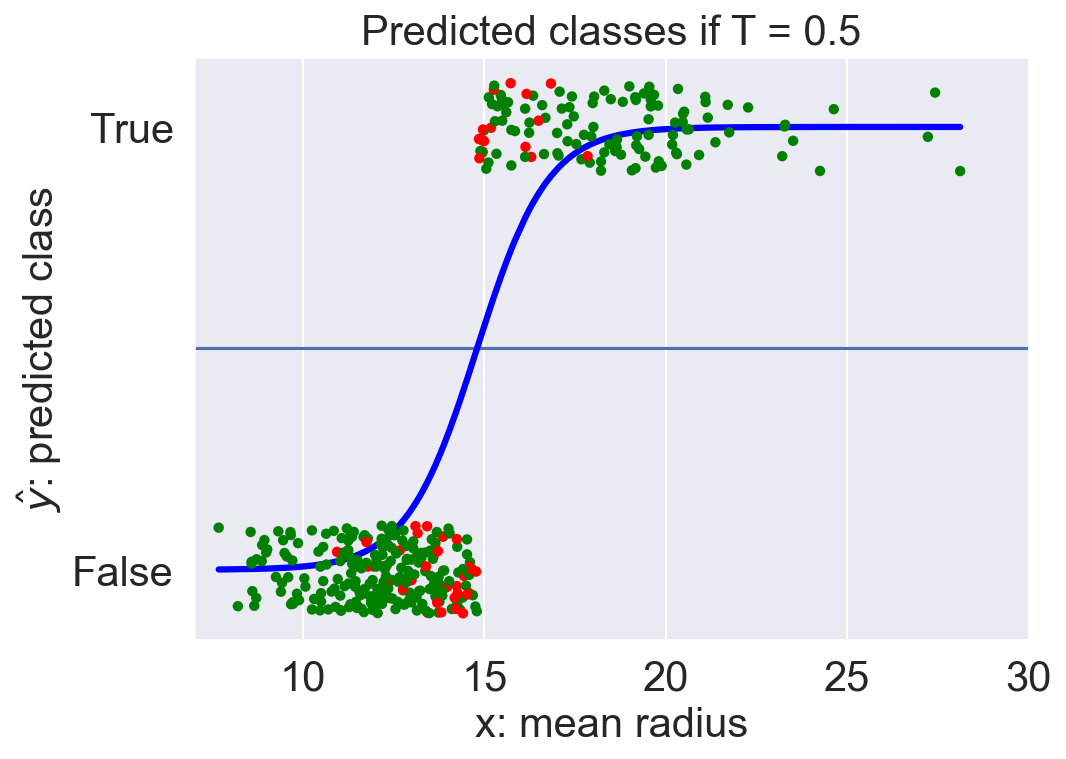

In [97]:
preds = (model.predict_proba(X)[:,1] >= 0.5)
    
fig = plt.figure()
color_palette = {False:'red', True:'green'}
fig = sns.stripplot(x=X.squeeze(), y=preds, 
              jitter = 0.1, orient='h', hue= preds==Y, 
              palette = color_palette);

plt.gca().invert_yaxis()
plt.xlabel('x: mean radius')
plt.ylabel(r'$\hat{y}$: predicted class')
plt.xlim((7, 30))
plt.axhline(y=0.50, label='T = {}'.format(0.50))

f = sns.lineplot(x= X.squeeze(), y=model.predict_proba(X)[:,1],
                 color='blue', linewidth=3)
plt.setp(f.get_legend().get_texts(), fontsize='10');
plt.title("Predicted classes if T = {}".format(0.50))

plt.legend().remove()

 The red datapoints represent data that was incorrectly classified by our model.

<br/><br/>

Let's build a DataFrame to store this information:

In [100]:
# in case you want to see all of the probabilities and predictions
def make_prediction_df(X, Y, model):
    # assume X has one feature and that model is already fit 
    Prob = model.predict_proba(X)
    Y_hat = model.predict(X)
    df = pd.DataFrame({"X": X.squeeze(),
                       "Y": Y,
                       "P(Y = 1 | x)": Prob[:,1],
                       "Y_hat": Y_hat})
    return df
    
predict_train_df = make_prediction_df(X, Y, model)
predict_train_df

,X,Y,P(Y = 1 | x),Y_hat
0,11.800,0,0.044233,0
1,17.020,1,0.905723,1
2,9.683,0,0.005289,0
3,10.950,1,0.019042,0
4,19.440,1,0.991303,1
...,...,...,...,...
359,15.000,0,0.549286,1
360,12.880,0,0.122481,0
361,15.500,1,0.670148,1
362,21.100,1,0.998395,1


---

<br/><br/><br/>

# Performance Metrics

In [102]:
X_val = data_val[['mean radius']].to_numpy()
Y_val = data_val['malignant'].to_numpy()

<br/>

### Accuracy

First, let's compute the **accuracy** of our `model` on our **training** dataset.



In [104]:
def accuracy(X, Y):
    return np.mean(model.predict(X) == Y)


In [105]:
# training accuracy
print("Training set accuracy:",accuracy(X, Y))

Training set accuracy: 0.8763736263736264


As per usual, `scikit-learn` can do this for us. The `.score` method of a `LogisticRegression` classifier gives us the accuracy of it.

In [107]:
# Accuracy for training set:
model.score(X, Y)

0.8763736263736264

We can visualize this in the plot below.

In [109]:
def threshold_plot(t, X, Y, Prob_hat_one):
    preds = (model.predict_proba(X)[:,1] >= t)
    fig = plt.figure()
    color_palette = {False:'red', True:'green'}
    fig = sns.stripplot(x=X.squeeze(), y=preds, 
              jitter = 0.1, orient='h', hue= preds==Y, 
              palette = color_palette);
    plt.gca().invert_yaxis()
    plt.xlabel('x: mean radius')
    plt.ylabel(r'$\hat{y}$: predicted class')
    plt.xlim((7, 30))
    plt.axhline(y=t, label='T = {}'.format(t))
    f = sns.lineplot(x= X.squeeze(), y=Prob_hat_one,
                 color='blue', linewidth=3)
    plt.setp(f.get_legend().get_texts(), fontsize='10');
    plt.title("Predicted classes if T = {}".format(t))
    plt.legend().remove()
    

Recall that sklearn's `model.predict()` will predict 1 if $P(Y = 1 | x) \geq 0.5$, and 0 otherwise.

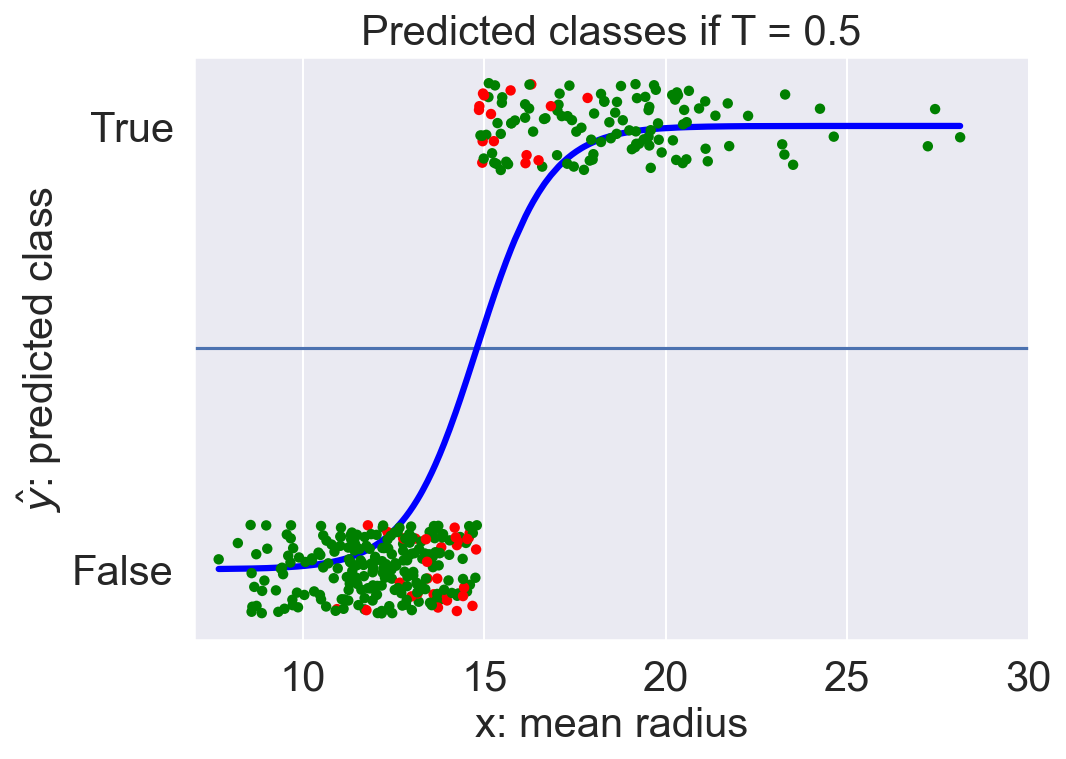

In [111]:
threshold_plot(0.50, X, Y, model.predict_proba(X)[:, 1])

So 87.6% of all the datapoints are green.  (The red datapoints represent data that was incorrectly classified by our model.

What about our **validation** set?


/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



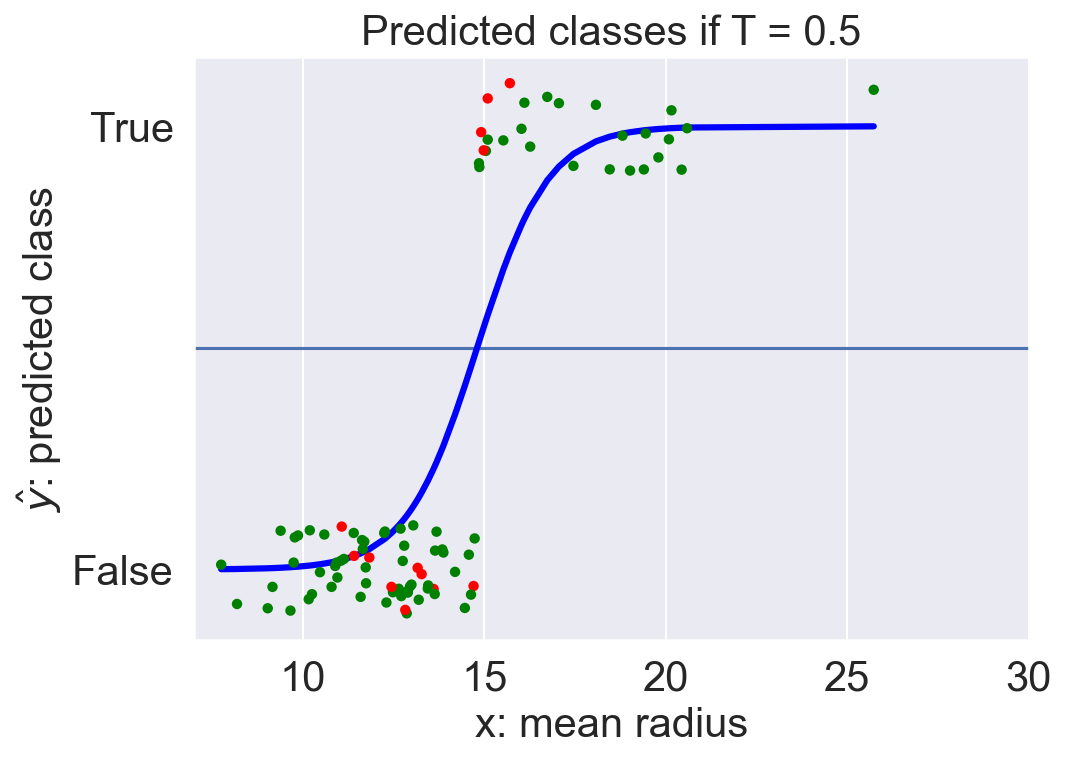

In [113]:
threshold_plot(0.50, X_val, Y_val, model.predict_proba(X_val)[:, 1])

In [114]:
print("Validation set accuracy:",accuracy(X_val, Y_val))

Validation set accuracy: 0.8571428571428571


/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



In [115]:
# Accuracy for validation set set:
model.score(X_val, Y_val)

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



0.8571428571428571

### Precision and Recall


It seems we can get a very high accuracy. What about precision and recall?  
- **Precision** (also called positive predictive value) is the fraction of true positives among the total number of data points predicted as positive.  
- **Recall** (also known as sensitivity) is the fraction of true positives among the total number of data points with positive labels.

Precision measures the ability of our classifier to not predict negative samples as positive (i.e., avoid false positives), while recall is the ability of the classifier to find all the positive samples (i.e., avoid false negatives).

Below is a graphical illustration of precision and recall, modified slightly from [Wikipedia](https://en.wikipedia.org/wiki/Precision_and_recall):

![alternative text](images/precision_recall.png)


Mathematically, Precision and Recall are defined as:
$$
\text{Precision} = \frac{n_{true\_positives}}{n_{true\_positives} + n_{false\_positives}} = \frac{TP}{TP+FP}
$$

$$
\text{Recall} = \frac{n_{true\_positives}}{n_{true\_positives} + n_{false\_negatives}}=\frac{TP}{TP+FN}
$$

Use the formulas above to compute the precision and recall for the **validation set** using the `lr` model trained using sklearn.

In [118]:
Y_hat_val = model.predict(X_val)
tp = np.sum((Y_hat_val == 1) & (Y_val == 1))
tn = np.sum((Y_hat_val == 0) & (Y_val == 0))

fp = np.sum((Y_hat_val == 1) & (Y_val == 0))
fn = np.sum((Y_hat_val == 0) & (Y_val == 1))
tp, tn, fp, fn

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



(23, 55, 4, 9)

In [119]:
precision = tp / (tp + fp)
precision

0.8518518518518519

In [120]:
recall = tp / (tp + fn)
recall

0.71875

It's important to remember that these values are all for the threshold of $T = 0.5$, which is `scikit-learn`'s default.

## Confusion matrix and Built-In Scipy Functions to Calculate Precision and Recall

Our good old friend `scikit-learn` has an in-built confusion matrix method (of course it does).

In [123]:
from sklearn.metrics import confusion_matrix

# Be careful – confusion_matrix takes in y_true as the first parameter and y_pred as the second.
# Don't mix these up!
cm = confusion_matrix(Y_val, model.predict(X_val))
cm

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



array([[55,  4],
       [ 9, 23]])

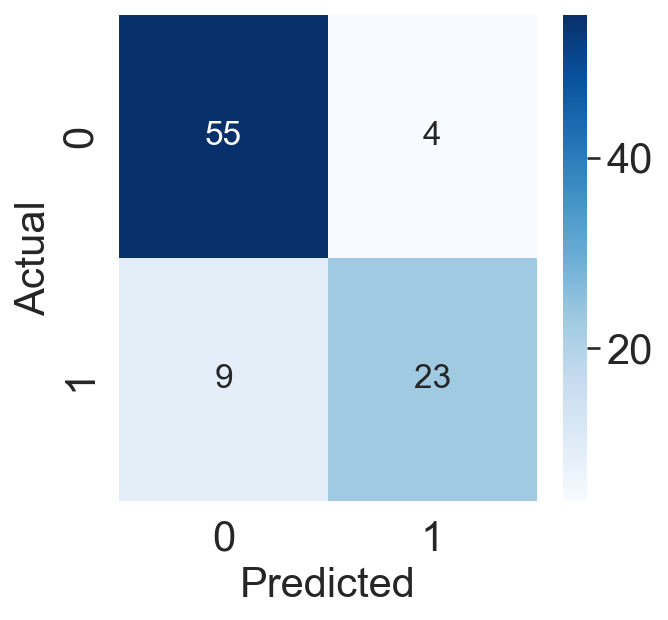

In [124]:

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap = 'Blues', annot_kws = {'size': 16})
plt.xlabel('Predicted')
plt.ylabel('Actual');
savefig("cm")

In [125]:
from sklearn.metrics import precision_score

precision_score(Y_val, Y_hat_val)

0.8518518518518519

In [126]:
from sklearn.metrics import recall_score
recall_score(Y_val, Y_hat_val)

0.71875

These numbers match what we calculated manually  above.

---

<br/><br/>

# Adjusting the Classification Threshold

What does a prediction of 1 mean with the default sklearn threshold of $T = 0.5$?

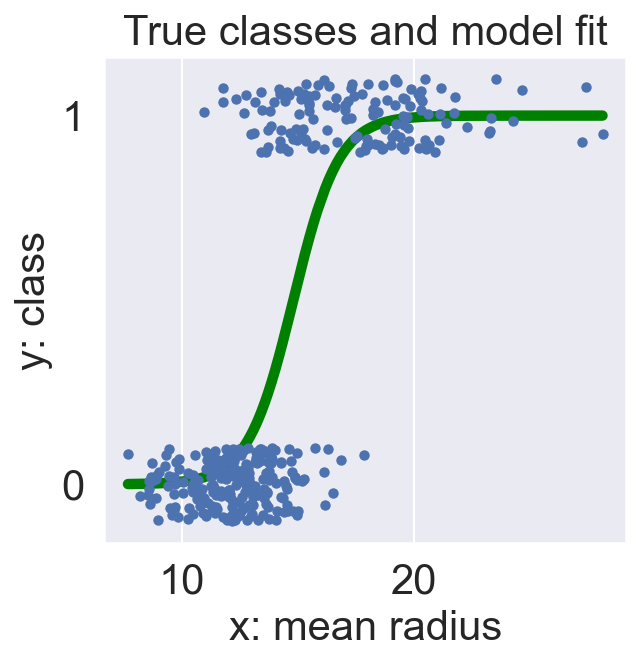

In [129]:
Prob_hat_one = model.predict_proba(X)[:, 1]

plt.figure(figsize=(4,4))
sns.stripplot(x=X.squeeze(), y=Y, 
              jitter = 0.1, orient='h');
sns.lineplot(x= X.squeeze(), y=Prob_hat_one,
             color='green', linewidth=5, label=r'$\hat{P}_{\theta}(Y = 1 | x)$')
plt.gca().invert_yaxis()
plt.xlabel('x: mean radius')
plt.ylabel('y: class')
plt.title("True classes and model fit")
plt.legend().remove()
savefig("true")

What if we choose different thresholds?

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not 

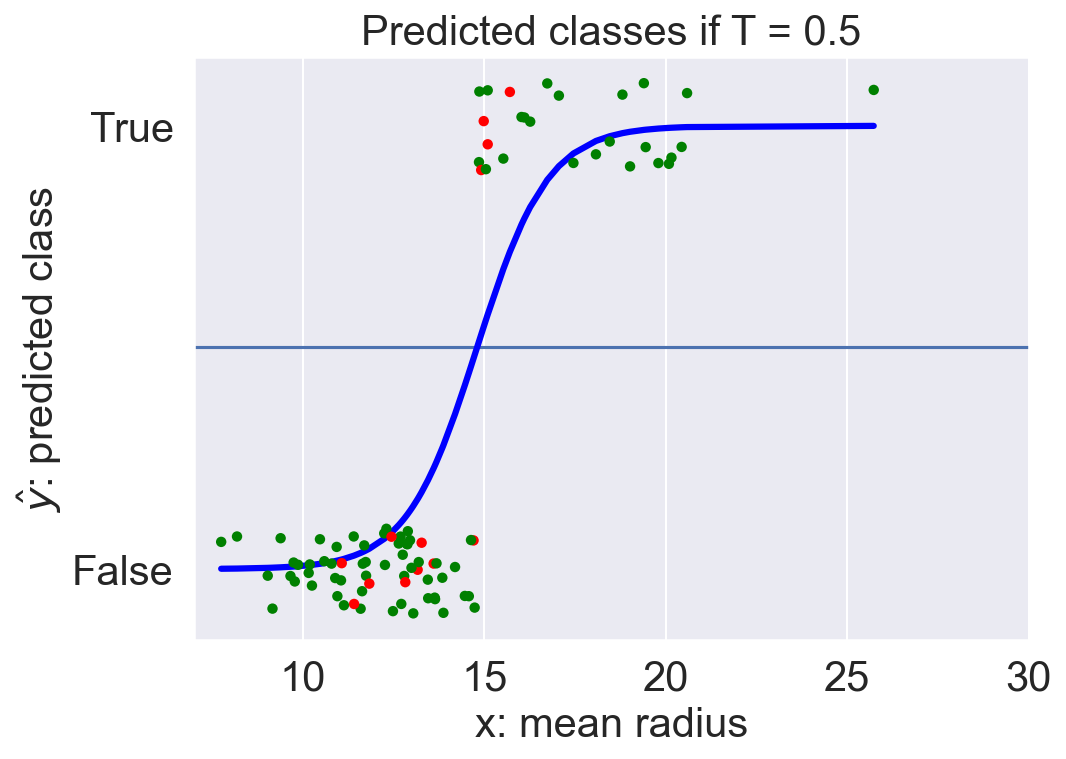

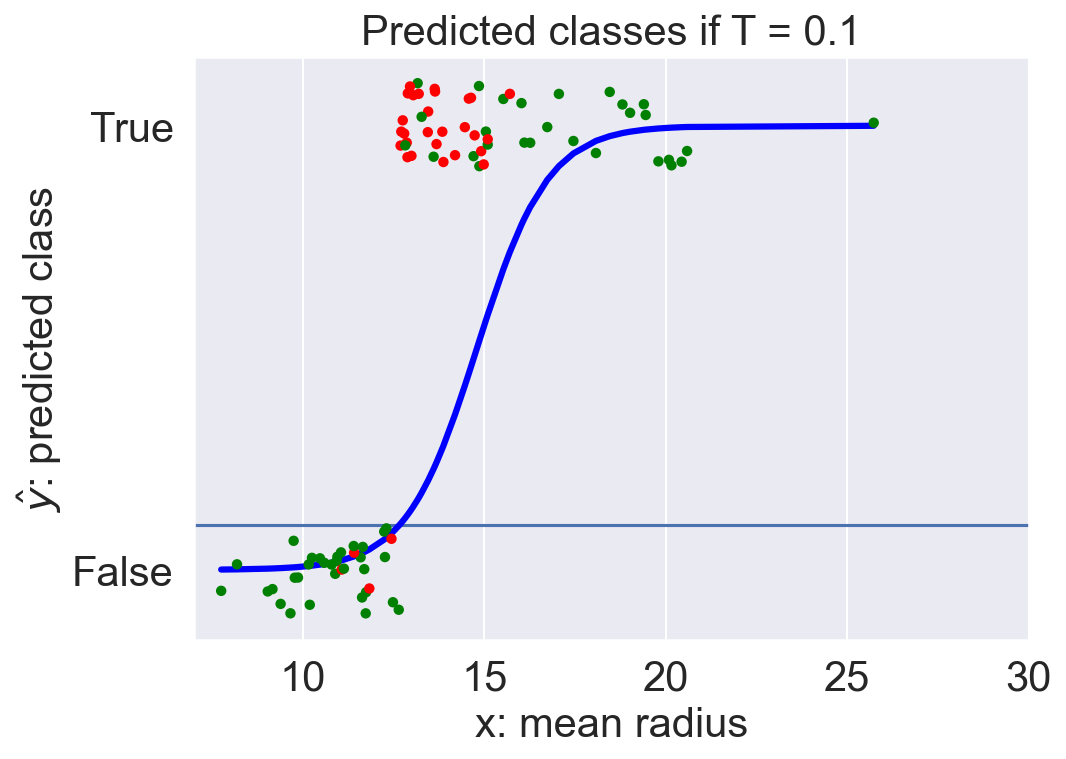

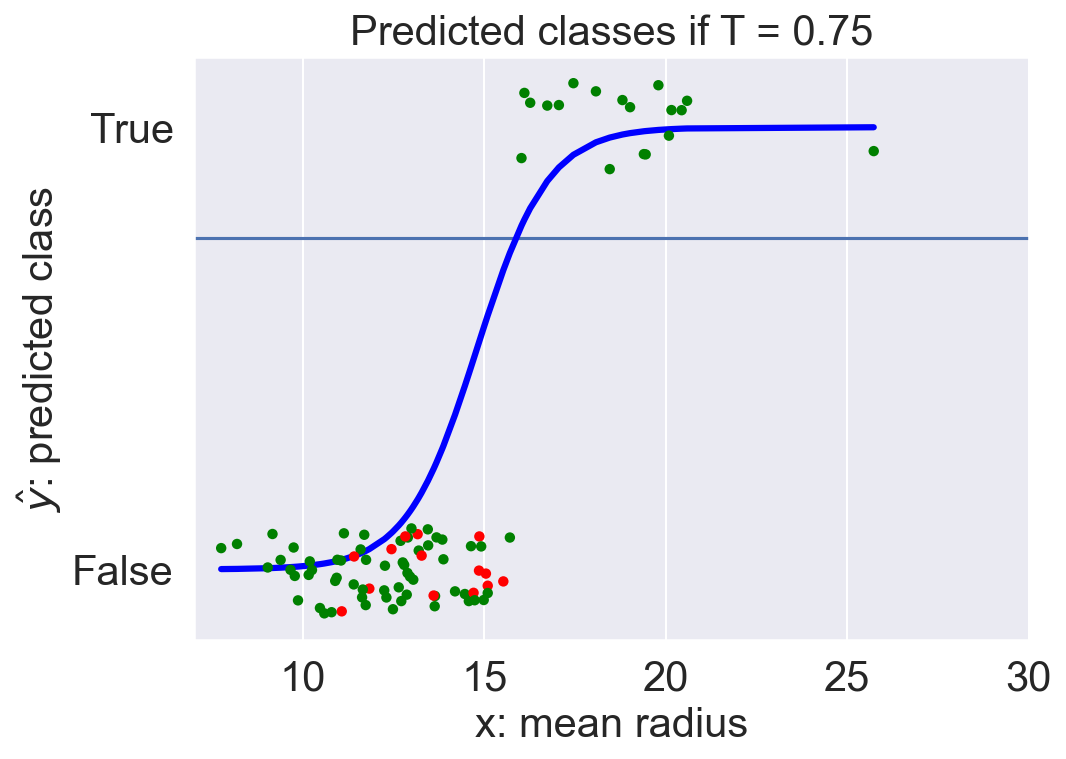

In [131]:
threshold_plot(0.50, X_val, Y_val, model.predict_proba(X_val)[:, 1])
threshold_plot(0.10, X_val, Y_val, model.predict_proba(X_val)[:, 1])
threshold_plot(0.75, X_val, Y_val, model.predict_proba(X_val)[:, 1])

<br/><br/>

# Choosing a Threshold

What is the best threshold for a given performance metric?

This depends on what we're using the data for.



---

<br/><br/>

# Adjusting the Classification Threshold

What does a prediction of 1 mean with the default sklearn threshold of $T = 0.5$?

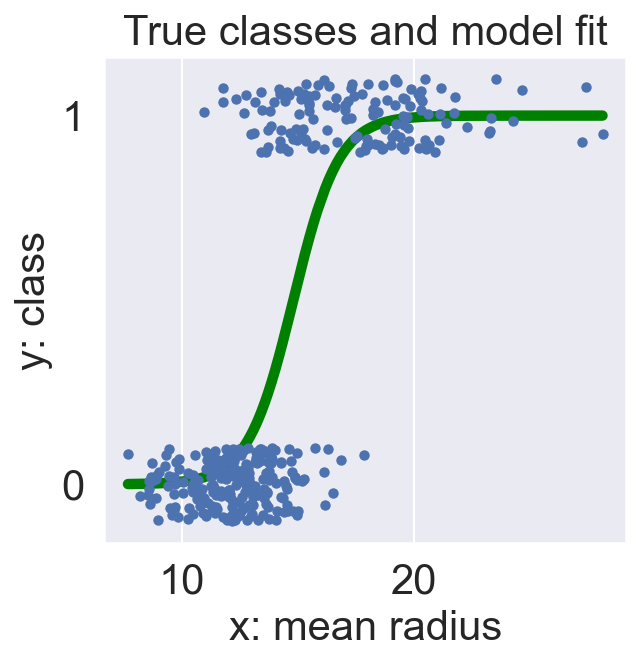

In [129]:
Prob_hat_one = model.predict_proba(X)[:, 1]

plt.figure(figsize=(4,4))
sns.stripplot(x=X.squeeze(), y=Y, 
              jitter = 0.1, orient='h');
sns.lineplot(x= X.squeeze(), y=Prob_hat_one,
             color='green', linewidth=5, label=r'$\hat{P}_{\theta}(Y = 1 | x)$')
plt.gca().invert_yaxis()
plt.xlabel('x: mean radius')
plt.ylabel('y: class')
plt.title("True classes and model fit")
plt.legend().remove()
savefig("true")

What if we choose different thresholds?

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not 

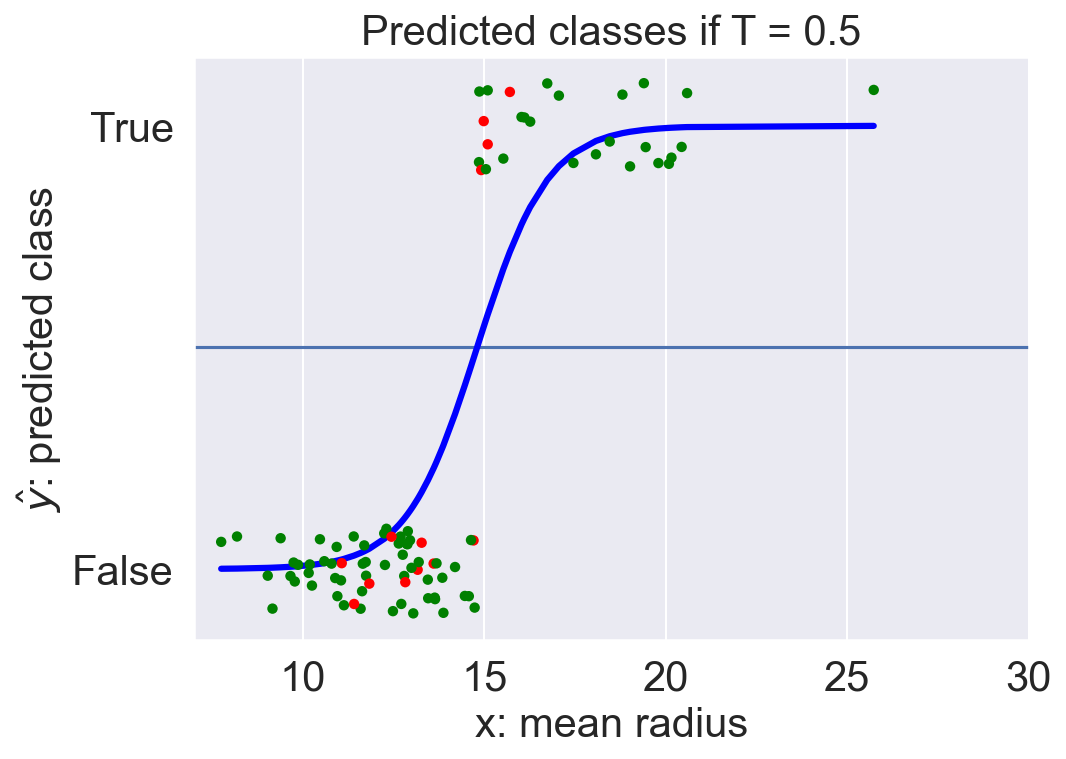

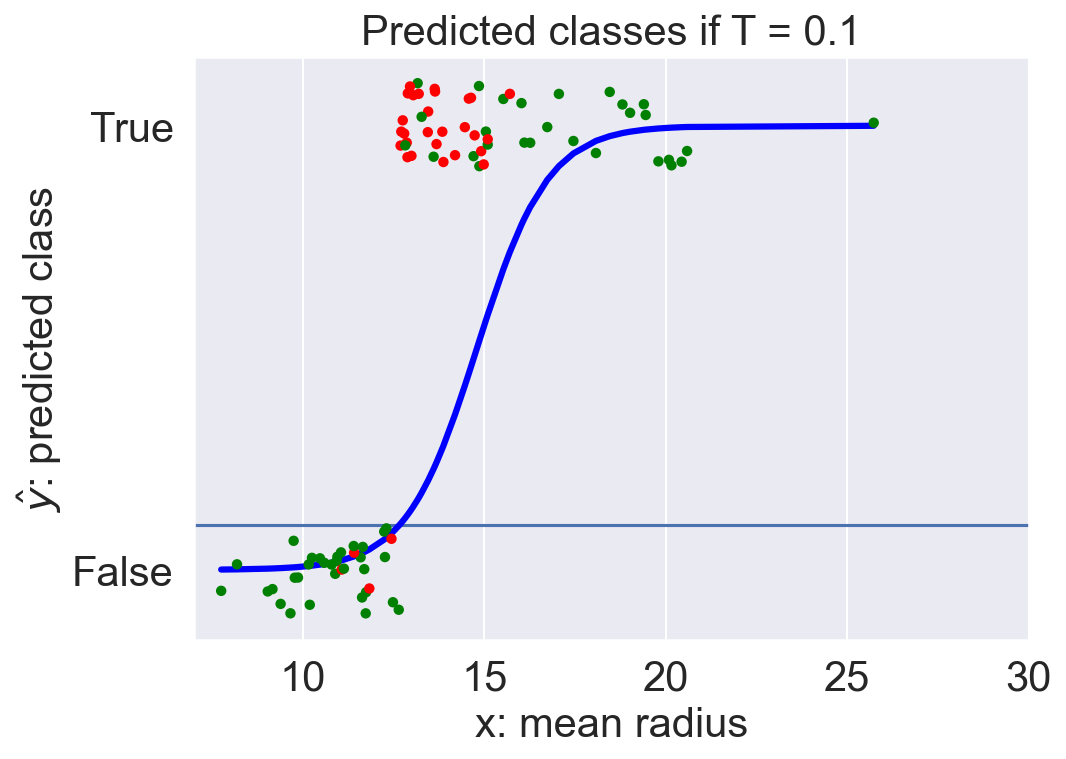

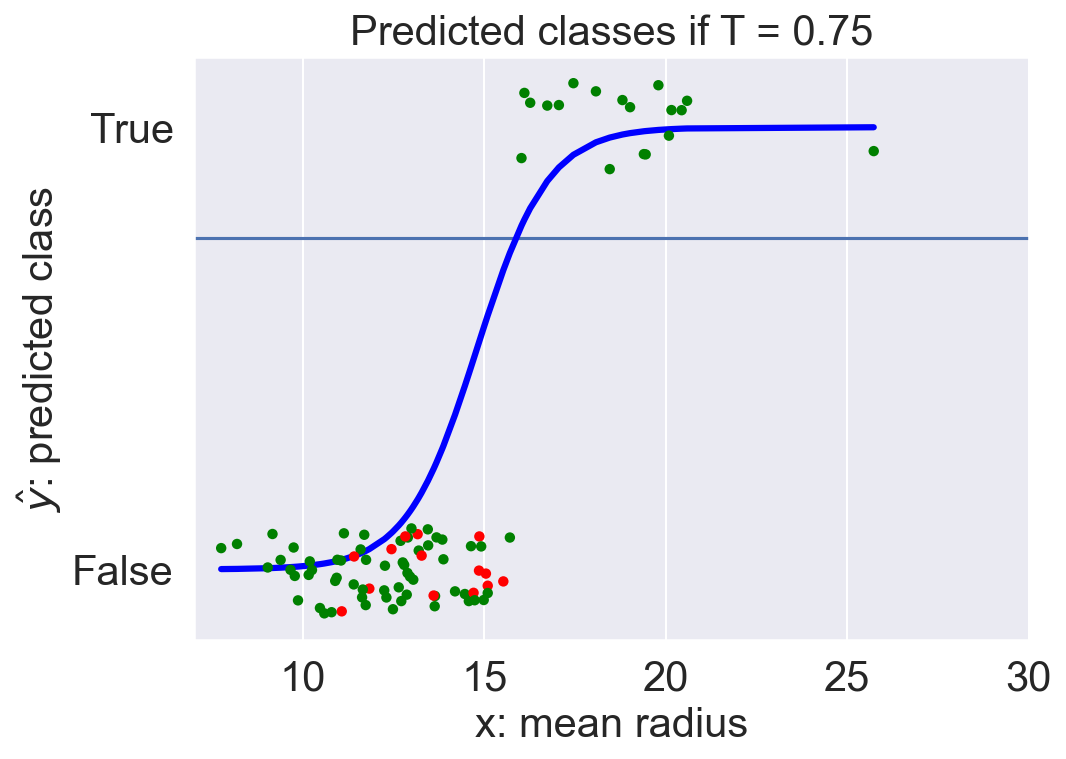

In [131]:
threshold_plot(0.50, X_val, Y_val, model.predict_proba(X_val)[:, 1])
threshold_plot(0.10, X_val, Y_val, model.predict_proba(X_val)[:, 1])
threshold_plot(0.75, X_val, Y_val, model.predict_proba(X_val)[:, 1])

<br/><br/>

# Choosing a Threshold

What is the best threshold for a given performance metric?

This depends on what we're using the data for.



## Accuracy vs. threshold, Precision vs. threshold, Recall vs. threshold

First we'll create a function `predict_threshold`, which takes in a model, X,  and a threshold and computes the predicted labels (1s and 0s) at that threshold.


In [134]:
def predict_threshold(model, X, T): 
    prob_one = model.predict_proba(X)[:, 1]
    return (prob_one >= T).astype(int)

Let's also create our own `accuracy_custom_threshold` function, that takes in
- a `model`
- a true `y`
- an `x`
- a `threshold`

And returns the accuracy of the predictions for our `model` with that threshold. Note that this function is not specific to our `model`, so we can use it later.

In [280]:
def accuracy_custom_threshold(model, X, y, threshold):
    y_pred = predict_threshold(model, X, threshold)
    return np.mean(y_pred == y)

In [286]:
accuracy_custom_threshold(model,X, Y, 0.5)

0.8763736263736264

In [294]:
accuracy_custom_threshold(model,X, Y, 0.75)

0.8461538461538461

In [282]:
accuracy_custom_threshold(model,X_val, Y_val, 0.5)

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



0.8571428571428571

This is the same accuracy that `model.score` gave us before, so we should be good to go.

Let's plot what this accuracy looks like, for various thresholds:

In [139]:
thresholds = np.linspace(0, .99, 100)
accs = [accuracy_custom_threshold(model,X_val, Y_val,
                                  t) for t in thresholds]

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not 

In [140]:
fig = px.line(x=thresholds, y=accs)
fig.update_xaxes(title="Threshold")
fig.update_yaxes(title="Validation Accuracy")

In [141]:
# The threshold that maximizes validation accuracy
np.argmax(accs)

46

<br/>
<br/>

In practice we should use **cross validation** to see what threshold maximizes accuracy. (We'll do this on the entire train/val set:)

In [143]:
X_tr_val = data_tr_val[['mean radius']].to_numpy()
Y_tr_val = data_tr_val['malignant'].to_numpy()

In [144]:
def predict_threshold(model, X, T): 
    prob_one = model.predict_proba(X)[:, 1]
    return (prob_one >= T).astype(int)

In [145]:
from sklearn import metrics

# Used for sklearn's cross_val_score
def make_scorer(metric, T):
    return lambda model, X, Y: metric(Y_tr_val, predict_threshold(model, X_tr_val, T)) 

def acc_scorer(T):
    return make_scorer(metrics.accuracy_score, T)

In [146]:
from sklearn.model_selection import cross_val_score
cv_accs = [
    np.mean(cross_val_score(model, X_tr_val, Y_tr_val, 
                            scoring=acc_scorer(t), 
                            cv=5))
    for t in thresholds
]

In [147]:
fig = px.line(x=thresholds, y=cv_accs, title="Cross-Validated Accuracy vs. Threshold")
fig.update_xaxes(title="threshold")
fig.update_yaxes(title="Accuracy")

In [148]:
# The threshold that maximizes cross-validation accuracy
np.argmax(cv_accs)

55

## Accuracy vs. threshold, Precision vs. threshold, Recall vs. threshold

First we'll create a function `predict_threshold`, which takes in a model, X,  and a threshold and computes the predicted labels (1s and 0s) at that threshold.


We will make similar helper functions for precision and recall, and make similar plots.

In [150]:
def precision_custom_threshold(model, X, y, threshold):
    y_pred = predict_threshold(model, X, threshold)
    tp = np.sum((y_pred == 1) & (y == 1))
    fp = np.sum((y_pred == 1) & (y == 0))
    return tp / (tp + fp)


precision_custom_threshold(model, X_val, Y_val, 0.5)

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



0.8518518518518519

In [151]:
def recall_custom_threshold(model, X, y, threshold):
    y_pred = predict_threshold(model, X, threshold)
    tp = np.sum((y_pred == 1) & (y == 1))
    fn = np.sum((y_pred == 0) & (y == 1))
    return tp / (tp + fn)

recall_custom_threshold(model, X_val, Y_val, 0.5)

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



0.71875

In [152]:
precs = [precision_custom_threshold(model, X_val, Y_val,
                                  t) for t in thresholds]

recs = [recall_custom_threshold(model, X_val, Y_val,t) for t in thresholds]

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not 

In [153]:
fig = go.Figure()
fig.add_trace(go.Scatter(name = 'Precision', x = thresholds, y = precs))
fig.add_trace(go.Scatter(name = 'Recall', x = thresholds, y = recs))
fig.update_xaxes(title="Threshold")
fig.update_yaxes(title="Proportion")
fig.update_layout(width=600, height=600)

## Precision-Recall Curves

We can also plot precision vs. recall.

In [155]:
fig = px.line(x=recs, y=precs, hover_name=thresholds)
fig.update_xaxes(title="Recall")
fig.update_yaxes(title="Precision")

`scikit-learn` can also do this for us.

In [157]:
from sklearn.metrics import precision_recall_curve

In [158]:
precision, recall, threshold = (
    metrics.precision_recall_curve(Y_val, model.predict_proba(X_val)[:, 1]))

tpr_df = pd.DataFrame({"threshold":threshold, 
                       "precision":precision[:-1], "recall": recall[:-1], })


/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



In [159]:
fig = px.line(x=recall[:-1], y = precision[:-1], hover_name=threshold)
fig.update_xaxes(title="Recall")
fig.update_yaxes(title="Precision")
fig

Same thing, just a bit more granular.


## ROC Curves

<br/><br/>



This is the curve of False Positive vs True Positive for different thresholds.  

To start, we'll plot the TPR and FPR rates vs. threshold:

In [163]:
bc_model = model        # Fit to breast cancer dataset
def predict_threshold(model, X, T): 
    prob_one = model.predict_proba(X)[:, 1]
    return (prob_one >= T).astype(int)


def tpr_threshold(X, Y, T): # This is recall
    Y_hat = predict_threshold(bc_model, X, T)
    return np.sum((Y_hat == 1) & (Y == 1)) / np.sum(Y == 1)

def fpr_threshold(X, Y, T):
    Y_hat = predict_threshold(bc_model, X, T)
    return np.sum((Y_hat == 1) & (Y == 0)) / np.sum(Y == 0)


In [164]:
# Compute for different thresholds on train set
thresholds = np.linspace(0, 1, 100)
tprs = [tpr_threshold(X_val, Y_val, t) for t in thresholds]
fprs = [fpr_threshold(X_val, Y_val, t) for t in thresholds]

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not 

In [165]:
fig = go.Figure()
fig.add_trace(go.Scatter(name = 'TPR', x = thresholds, y = tprs))
fig.add_trace(go.Scatter(name = 'FPR', x = thresholds, y = fprs))
fig.update_xaxes(title="Threshold")
fig.update_yaxes(title="Proportion")

Some observations:
* T = 0 means everything is positive.
    * Then there are no TN (all of them are FP). → FPR = 1
    * We identified all true 1’s as 1, so TPR = recall = 1
* T = 1 means everything is negative.
    * Then there are no FP (all of them are TN). → FPR = 0
    * We identified zero true 1’s as 1, so TPR = recall = 0

In other words, TPR and FPR are both inversely proportional to the classification threshold T.

As we increase T, both TPR and FPR decrease.
* A decreased TPR is bad (detecting fewer positives).
* A decreased FPR is good (fewer false positives).



## Putting this all together: ROC curve


In [168]:
fig = px.line(x=fprs, y = tprs, hover_name=thresholds, title="ROC Curve")
fig.update_xaxes(title="False Positive Rate")
fig.update_yaxes(title="True Positive Rate")
fig

 We can measure how "good" this curve is using the Area Under the Curve.  The closer this number is to 1, the "better" this  model is.  
 


In [170]:

metrics.roc_auc_score(Y_val, model.predict_proba(X_val)[:, 1])



/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



0.8800317796610171

Or, using built-in methods from sklearn:

In [172]:
from sklearn.metrics import roc_curve

In [173]:
fpr, tpr, threshold = roc_curve(Y_val, model.predict_proba(X_val)[:, 1])

/opt/anaconda3/envs/py10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



In [174]:
fig = px.line(x=fpr, y = tpr, hover_name=threshold)
fig.update_xaxes(title="False Positive Rate")
fig.update_yaxes(title="True Positive Rate")
fig

For a random classifier:

In [176]:
fpr, tpr, threshold = roc_curve(Y_val, np.random.uniform(0, 1, len(Y_val)))

In [177]:
fig = px.line(x=fpr, y = tpr, hover_name=threshold)
fig.update_xaxes(title="False Positive Rate")
fig.update_yaxes(title="True Positive Rate")
fig